# Baseline vs skeleton-graph junction fix + direct MLP/CNN vector regression

This notebook compares rule-based vector reconstruction with direct learned raster-to-vector models. The MLP and CNN predict line vectors directly from pixels using the synthetic target vectors as labelled data for backpropagation.


In [1]:
import random
import math
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# New data every time by default.
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

IMG_SIZE = 128
MAX_VECTORS = 20
LINE_WIDTH = 1

N_TRAIN_IMAGES = 600
N_TEST = 80

PATCH_SIZE = 9
PATCH_RADIUS = PATCH_SIZE // 2
JUNCTION_RADIUS = 2

BATCH_SIZE = 512
MLP_EPOCHS = 100
CNN_EPOCHS = 100
LEARNING_RATE = 3e-4

# Controls the final vector cleanup.
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## Engineering drawing geometry configuration

These controls make the synthetic data and the final evaluation prefer engineering-style geometry: whole-degree angles, whole-pixel lengths, and stronger weighting for 90°, then 45°, 60°, 30°, and 10° angle families.


In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## 1. Synthetic vector data

Synthetic generator is changed here:

- line endpoints are integer pixel-centre grid points, from `0` to `IMG_SIZE - 1`;
- line direction is sampled from weighted engineering angle families, highest priority first: 90°, 45°, 60°, 30°;
- stroke weight varies per line between 0.5 and 3 pixels;
- dataset size, number of random items per image, stroke fading, and raster noise are editable in `SYNTHETIC_DATA_CONFIG`.


(600, 128, 128) 600
Synthetic data controls:
{'n_train_images': 600, 'n_test_images': 80, 'min_items_per_image': 1, 'max_items_per_image': 20, 'min_line_length_px': 12, 'margin_px': 4, 'line_width_range_px': (0.5, 3.0), 'stroke_fade_range': (0.9, 1.0), 'raster_noise_std': 0.0, 'angle_family_weights': {90: 8.0, 45: 4.0, 60: 2.0, 30: 1.0}, 'angle_rounding_deg': 1, 'max_line_generation_attempts': 1000}

Example line styles for first training image:
  line 0: {'width_px': 2.081, 'darkness': 0.934, 'angle_family': 45, 'target_angle_deg': 0, 'actual_angle_deg': 0.0}
  line 1: {'width_px': 1.424, 'darkness': 0.932, 'angle_family': 90, 'target_angle_deg': 0, 'actual_angle_deg': 0.0}
  line 2: {'width_px': 0.578, 'darkness': 0.938, 'angle_family': 90, 'target_angle_deg': 0, 'actual_angle_deg': 0.0}
  line 3: {'width_px': 2.506, 'darkness': 0.998, 'angle_family': 45, 'target_angle_deg': 0, 'actual_angle_deg': 0.0}
  line 4: {'width_px': 0.62, 'darkness': 0.939, 'angle_family': 90, 'target_angle_

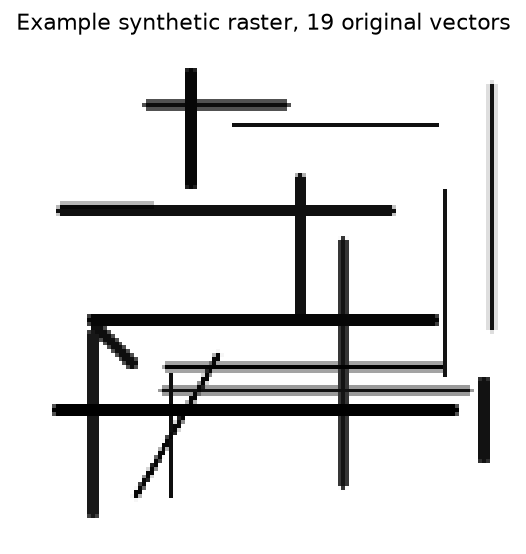

In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    """Clip a point to the valid pixel-centre grid: 0 ... img_size - 1."""
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


# Synthetic-data controls.
# Edit only this dictionary when you want more/fewer examples, more/fewer lines,
# more/less stroke fade, or more/less raster noise.
SYNTHETIC_DATA_CONFIG = {
    "n_train_images": N_TRAIN_IMAGES,   # number of random training drawings to create
    "n_test_images": N_TEST,            # number of random test drawings to create

    "min_items_per_image": 1,           # minimum random line items in one drawing
    "max_items_per_image": MAX_VECTORS, # maximum random line items in one drawing

    "min_line_length_px": 12,           # measured between integer pixel-centre endpoints
    "margin_px": 4,                     # keep endpoints away from the image border

    "line_width_range_px": (0.5, 3.0),  # variable raster stroke weight per line
    "stroke_fade_range": (0.90, 1.00),  # 1.0 = black/strong, lower values = faded/lighter
    "raster_noise_std": 0.00,           # try 0.02, 0.05, 0.10 for increasing Gaussian noise

    # Angle-family priority. The selected family creates angles that are multiples of that degree.
    # Because 90-degree angles also appear inside 45/60/30 families, they naturally occur often.
    "angle_family_weights": {
        90: 8.0,   # highest priority: horizontal/vertical/right-angle drawing
        45: 4.0,
        60: 2.0,
        30: 1.0,
    },

    # Endpoints must be grid points, so 30/60 degree lines are represented by the closest
    # integer endpoint vector whose rounded angle is still the requested whole-degree angle.
    "angle_rounding_deg": 1,
    "max_line_generation_attempts": 1000,
}

# Keep the original global names consistent for all later notebook cells.
N_TRAIN_IMAGES = SYNTHETIC_DATA_CONFIG["n_train_images"]
N_TEST = SYNTHETIC_DATA_CONFIG["n_test_images"]
MAX_VECTORS = SYNTHETIC_DATA_CONFIG["max_items_per_image"]


def bresenham_line(x0, y0, x1, y1):
    """Return integer grid pixels touched by a 1-pixel digital line."""
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    """Distance from every pixel centre to a finite line segment."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    x0, y0, x1, y1 = map(float, [x0, y0, x1, y1])
    vx, vy = x1 - x0, y1 - y0
    denom = vx * vx + vy * vy
    if denom <= 1e-12:
        return np.hypot(xx - x0, yy - y0)

    t = ((xx - x0) * vx + (yy - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    qx = x0 + t * vx
    qy = y0 + t * vy
    return np.hypot(xx - qx, yy - qy)


def rasterise_vectors(
    vectors,
    img_size=IMG_SIZE,
    line_width=LINE_WIDTH,
    line_styles=None,
    add_noise=False,
    noise_std=None,
):
    """Rasterise vectors onto a white image.

    Important compatibility rule:
    - rasterise_vectors(pred_vectors, IMG_SIZE) keeps the original 1-pixel Bresenham binary output.
    - synthetic input images pass line_styles, enabling variable width, fading, and optional noise.
    """
    image = np.ones((img_size, img_size), dtype=np.float32)

    # Preserve the original downstream behaviour for predictions and metric rasters.
    if line_styles is None and line_width == LINE_WIDTH and not add_noise:
        for vector in vectors:
            x0, y0, x1, y1 = vector[:4]
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)
            for x, y in bresenham_line(x0, y0, x1, y1):
                image[y, x] = 0.0
        return image.astype(np.float32)

    if line_styles is None:
        line_styles = [{} for _ in vectors]

    for vector, style in zip(vectors, line_styles):
        x0, y0, x1, y1 = vector[:4]
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        width_px = float(style.get("width_px", line_width))
        darkness = float(style.get("darkness", 1.0))
        width_px = max(0.01, width_px)
        darkness = float(np.clip(darkness, 0.0, 1.0))

        # A soft half-pixel edge keeps fractional weights such as 0.5 visible.
        dist = pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size)
        half_width = width_px / 2.0
        edge_softness = 0.5
        coverage = np.clip((half_width + edge_softness - dist) / edge_softness, 0.0, 1.0)

        # Darken the raster where this stroke exists. Overlapping strokes remain dark.
        image = np.minimum(image, 1.0 - darkness * coverage)

    if add_noise:
        if noise_std is None:
            noise_std = SYNTHETIC_DATA_CONFIG["raster_noise_std"]
        noise_std = float(noise_std)
        if noise_std > 0:
            image = image + np.random.normal(0.0, noise_std, image.shape).astype(np.float32)
            image = np.clip(image, 0.0, 1.0)

    return image.astype(np.float32)


def line_angle_deg(vector):
    x0, y0, x1, y1 = vector[:4]
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180


def rounded_line_angle_deg(vector, rounding_deg=1):
    angle = line_angle_deg(vector)
    return (round(angle / rounding_deg) * rounding_deg) % 180


def sample_angle_family(config=SYNTHETIC_DATA_CONFIG):
    families = list(config["angle_family_weights"].keys())
    weights = list(config["angle_family_weights"].values())
    family = random.choices(families, weights=weights, k=1)[0]

    # For a family value of 45, choose from 0, 45, 90, 135.
    # For 30, choose from 0, 30, 60, 90, 120, 150.
    base_angles = list(range(0, 180, int(family)))
    target_angle = random.choice(base_angles)

    # Randomly reverse direction while preserving the undirected line angle.
    directed_angle = target_angle + random.choice([0, 180])
    return family, target_angle, directed_angle


def make_grid_endpoint_vector(x0, y0, length_px, directed_angle_deg):
    """Convert a sampled angle/length into integer pixel-centre endpoints."""
    angle_rad = math.radians(directed_angle_deg)
    dx = int(round(math.cos(angle_rad) * length_px))
    dy = int(round(math.sin(angle_rad) * length_px))
    return int(x0), int(y0), int(x0 + dx), int(y0 + dy)


def random_line(img_size=IMG_SIZE, min_len=None, config=SYNTHETIC_DATA_CONFIG):
    """Generate one engineering-style vector with integer pixel-centre endpoints.

    The returned vector is always a 4-tuple `(x0, y0, x1, y1)` so all later notebook
    code remains compatible. Per-line raster style is returned separately.
    """
    if min_len is None:
        min_len = int(config["min_line_length_px"])

    margin = int(config["margin_px"])
    max_len = max(min_len, img_size - 1 - 2 * margin)
    rounding_deg = int(config["angle_rounding_deg"])

    for _ in range(int(config["max_line_generation_attempts"])):
        family, target_angle, directed_angle = sample_angle_family(config)
        length_px = random.randint(min_len, max_len)

        x0 = random.randint(margin, img_size - 1 - margin)
        y0 = random.randint(margin, img_size - 1 - margin)
        vector = make_grid_endpoint_vector(x0, y0, length_px, directed_angle)
        x0, y0, x1, y1 = vector

        if not (margin <= x1 <= img_size - 1 - margin and margin <= y1 <= img_size - 1 - margin):
            continue

        if math.hypot(x1 - x0, y1 - y0) < min_len:
            continue

        # Because endpoints are constrained to integer grid points, exact 30/60 degree
        # trigonometric coordinates are not always possible. This keeps the rounded
        # whole-degree angle constrained to the sampled target.
        if rounded_line_angle_deg(vector, rounding_deg) != target_angle % 180:
            continue

        line_width = random.uniform(*config["line_width_range_px"])
        darkness = random.uniform(*config["stroke_fade_range"])
        style = {
            "width_px": line_width,
            "darkness": darkness,
            "angle_family": family,
            "target_angle_deg": target_angle,
            "actual_angle_deg": line_angle_deg(vector),
        }
        return vector, style

    # Fallback: a clean horizontal grid-aligned line.
    y = margin
    vector = (margin, y, img_size - 1 - margin, y)
    style = {
        "width_px": float(np.mean(config["line_width_range_px"])),
        "darkness": float(np.mean(config["stroke_fade_range"])),
        "angle_family": 90,
        "target_angle_deg": 0,
        "actual_angle_deg": 0.0,
    }
    return vector, style


def generate_sample(max_vectors=None, img_size=IMG_SIZE, config=SYNTHETIC_DATA_CONFIG):
    if max_vectors is None:
        max_vectors = int(config["max_items_per_image"])

    min_items = int(config["min_items_per_image"])
    max_items = int(max_vectors)
    n = random.randint(min_items, max_items)

    vectors = []
    line_styles = []
    for _ in range(n):
        vector, style = random_line(img_size=img_size, config=config)
        vectors.append(vector)
        line_styles.append(style)

    image = rasterise_vectors(
        vectors,
        img_size=img_size,
        line_styles=line_styles,
        add_noise=True,
        noise_std=config["raster_noise_std"],
    )
    return image, vectors, line_styles


def generate_dataset(n_samples, return_styles=False, config=SYNTHETIC_DATA_CONFIG):
    images, vectors, styles = [], [], []
    for _ in range(int(n_samples)):
        img, vec, line_styles = generate_sample(config=config)
        images.append(img)
        vectors.append(vec)
        styles.append(line_styles)

    if return_styles:
        return np.stack(images), vectors, styles
    return np.stack(images), vectors


train_images, train_vectors, train_line_styles = generate_dataset(
    SYNTHETIC_DATA_CONFIG["n_train_images"],
    return_styles=True,
)
test_images, test_vectors, test_line_styles = generate_dataset(
    SYNTHETIC_DATA_CONFIG["n_test_images"],
    return_styles=True,
)

print(train_images.shape, len(train_vectors))
print('Synthetic data controls:')
print(SYNTHETIC_DATA_CONFIG)
print('\nExample line styles for first training image:')
for i, style in enumerate(train_line_styles[0]):
    print(f'  line {i}:', {k: round(v, 3) if isinstance(v, float) else v for k, v in style.items()})

plt.figure(figsize=(5, 5), dpi=130)
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title(f'Example synthetic raster, {len(train_vectors[0])} original vectors')
plt.axis('off')
plt.show()


## Original segment-intersection helper

Reused unchanged because the engineering junction-angle metric depends on it.

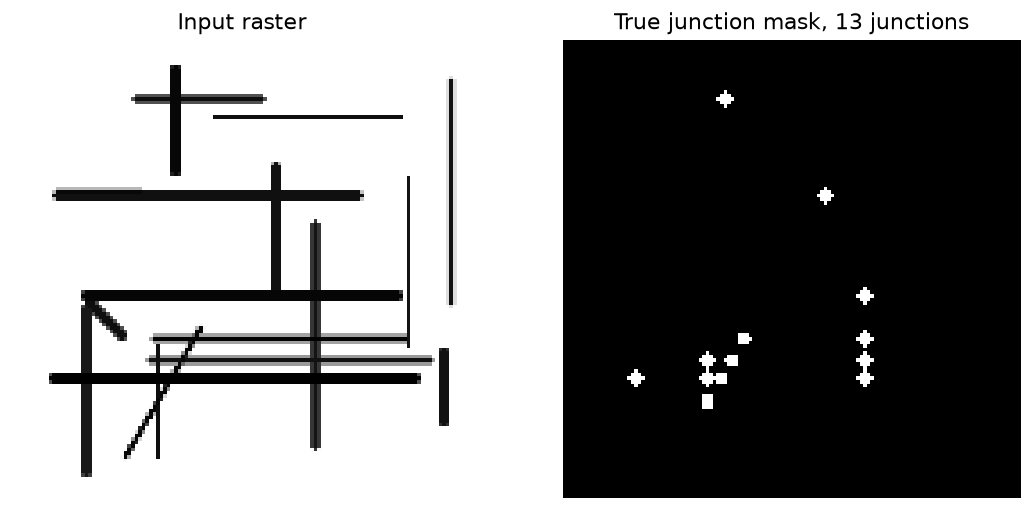

In [4]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None
    px = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / den

    def between(p, q, r):
        return min(p, r) - 1e-6 <= q <= max(p, r) + 1e-6

    if between(x1, px, x2) and between(y1, py, y2) and between(x3, px, x4) and between(y3, py, y4):
        return px, py
    return None


def junction_mask_from_vectors(vectors, img_size=IMG_SIZE, radius=JUNCTION_RADIUS):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    points = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is not None:
                points.append(p)
                cx, cy = p
                for y in range(max(0, int(cy - radius)), min(img_size, int(cy + radius) + 1)):
                    for x in range(max(0, int(cx - radius)), min(img_size, int(cx + radius) + 1)):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                            mask[y, x] = 1.0
    return mask, points

train_junction_masks = []
for vecs in train_vectors:
    m, _ = junction_mask_from_vectors(vecs)
    train_junction_masks.append(m)
train_junction_masks = np.stack(train_junction_masks)

sample_idx = 0
jm, pts = junction_mask_from_vectors(train_vectors[sample_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
ax[0].imshow(train_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Input raster')
ax[1].imshow(jm, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title(f'True junction mask, {len(pts)} junctions')
for a in ax:
    a.axis('off')
plt.show()

## Original baseline helpers

These definitions keep the original baseline junction rule: `neighbour_count >= 3` followed by `expand_mask(radius=1)`.

In [5]:
def threshold_stroke(image):
    return (image <= 0.5).astype(np.uint8)


def neighbour_count(mask, y, x):
    h, w = mask.shape
    c = 0
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and mask[yy, xx]:
                c += 1
    return c


def baseline_graph_junction_mask(image):
    # EXACT same rule as the original baseline: threshold -> neighbour_count >= 3 -> expand radius 1.
    stroke = threshold_stroke(image)
    out = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if neighbour_count(stroke, y, x) >= 3:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def expand_mask(mask, radius=1):
    out = mask.copy().astype(np.uint8)
    ys, xs = np.where(mask > 0)
    h, w = mask.shape
    for y, x in zip(ys, xs):
        for yy in range(max(0, y - radius), min(h, y + radius + 1)):
            for xx in range(max(0, x - radius), min(w, x + radius + 1)):
                if (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2:
                    out[yy, xx] = 1
    return out

## 6. Junction-aware vector reconstruction

This is the key change. Instead of creating many tiny line pieces inside a junction cluster, the algorithm contracts each predicted junction region to a single node and traces arms out from it.

This gives a middle ground:

- it does not delete the junction, so gaps are reduced;
- it does not fit many tiny lines inside the junction, so visual clutter is reduced.

In [6]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def connected_components(mask):
    mask = mask.astype(bool)
    h, w = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    comps = []
    for y in range(h):
        for x in range(w):
            if not mask[y, x] or seen[y, x]:
                continue
            q = deque([(y, x)])
            seen[y, x] = True
            comp = []
            while q:
                cy, cx = q.popleft()
                comp.append((cy, cx))
                for dx, dy in NEIGHBOURS_8:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and not seen[ny, nx]:
                        seen[ny, nx] = True
                        q.append((ny, nx))
            comps.append(comp)
    return comps


def make_node_map(stroke, junction_mask):
    h, w = stroke.shape
    node_map = -np.ones((h, w), dtype=np.int32)
    nodes = []

    # Junction nodes from connected predicted junction regions.
    for comp in connected_components(junction_mask & stroke):
        if len(comp) == 0:
            continue
        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        node_id = len(nodes)
        nodes.append({'type': 'junction', 'x': float(xs.mean()), 'y': float(ys.mean()), 'pixels': comp})
        for y, x in comp:
            node_map[y, x] = node_id

    # Endpoint nodes: stroke pixels with exactly one neighbour and not already in a junction.
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] >= 0:
            continue
        if neighbour_count(stroke, y, x) <= 1:
            node_id = len(nodes)
            nodes.append({'type': 'endpoint', 'x': float(x), 'y': float(y), 'pixels': [(y, x)]})
            node_map[y, x] = node_id
    return nodes, node_map


def distance_point_to_line(px, py, ax, ay, bx, by):
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    denom = vx * vx + vy * vy
    if denom == 0:
        return math.hypot(px - ax, py - ay)
    t = max(0.0, min(1.0, (wx * vx + wy * vy) / denom))
    qx, qy = ax + t * vx, ay + t * vy
    return math.hypot(px - qx, py - qy)


def fit_line_to_path(path_points):
    if len(path_points) < 2:
        return None
    pts = np.array([(x, y) for y, x in path_points], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def line_length(line):
    x0, y0, x1, y1 = line
    return math.hypot(x1 - x0, y1 - y0)


def trace_vectors_with_junctions(image, junction_mask):
    stroke = threshold_stroke(image)
    nodes, node_map = make_node_map(stroke, junction_mask.astype(np.uint8))
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def stroke_neighbours(y, x):
        out = []
        for dx, dy in NEIGHBOURS_8:
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
                out.append((yy, xx))
        return out

    # Start tracing from every node pixel to every adjacent non-node stroke pixel.
    for node_id, node in enumerate(nodes):
        for sy, sx in node['pixels']:
            for ny, nx in stroke_neighbours(sy, sx):
                if node_map[ny, nx] == node_id:
                    continue
                edge_key = tuple(sorted(((sy, sx), (ny, nx))))
                if edge_key in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key)
                prev = (sy, sx)
                cur = (ny, nx)
                end_node = node_map[cur]
                steps = 0

                while end_node < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = stroke_neighbours(*cur)
                    # avoid immediately going backwards unless there is no choice
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break
                    # Prefer moving into a node; otherwise continue along the least-branching direction.
                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = []
                        for p in candidates:
                            ek = tuple(sorted((cur, p)))
                            if ek not in visited_edges:
                                unvisited.append(p)
                        if not unvisited:
                            break
                        nxt = unvisited[0]

                    ek = tuple(sorted((cur, nxt)))
                    visited_edges.add(ek)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node = node_map[cur]
                    steps += 1

                if len(path) >= 2:
                    # Use contracted node centres at either end when present.
                    start_id = node_id
                    end_id = node_map[path[-1]]
                    raw_line = fit_line_to_path(path)
                    if raw_line is None:
                        continue
                    x0, y0, x1, y1 = raw_line
                    if start_id >= 0:
                        x0, y0 = nodes[start_id]['x'], nodes[start_id]['y']
                    if end_id >= 0:
                        x1, y1 = nodes[end_id]['x'], nodes[end_id]['y']
                    line = (x0, y0, x1, y1)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    debug = {
        'stroke': stroke,
        'junction_mask': junction_mask,
        'nodes': nodes,
        'node_map': node_map,
        'paths': paths,
    }
    return merge_collinear_vectors_fast(vectors), debug


def angle_of(line):
    x0, y0, x1, y1 = line
    return math.atan2(y1 - y0, x1 - x0)


def angle_diff(a, b):
    d = abs(a - b) % math.pi
    return min(d, math.pi - d)


def endpoint_distance(l1, l2):
    a = [(l1[0], l1[1]), (l1[2], l1[3])]
    b = [(l2[0], l2[1]), (l2[2], l2[3])]
    return min(math.hypot(x1-x2, y1-y2) for x1,y1 in a for x2,y2 in b)


def merged_line(l1, l2):
    pts = np.array([(l1[0], l1[1]), (l1[2], l1[3]), (l2[0], l2[1]), (l2[2], l2[3])], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def merge_collinear_vectors_fast(vectors, angle_tol_deg=8, endpoint_tol=4):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]
    angle_tol = math.radians(angle_tol_deg)
    for _ in range(MAX_MERGE_PASSES):
        used = [False] * len(vectors)
        new_vectors = []
        changed = False
        for i, vi in enumerate(vectors):
            if used[i]:
                continue
            current = vi
            used[i] = True
            for j in range(i + 1, len(vectors)):
                if used[j]:
                    continue
                vj = vectors[j]
                if angle_diff(angle_of(current), angle_of(vj)) <= angle_tol and endpoint_distance(current, vj) <= endpoint_tol:
                    current = merged_line(current, vj)
                    used[j] = True
                    changed = True
            if line_length(current) >= MIN_VECTOR_LENGTH:
                new_vectors.append(current)
        vectors = new_vectors
        if not changed:
            break
    return vectors


def reconstruct_vectors_from_image(image, method='baseline'):
    if method == 'baseline':
        jm = baseline_graph_junction_mask(image)
    elif method == 'mlp':
        jm = predict_junction_mask_mlp(image)
    elif method == 'cnn':
        jm = predict_junction_mask_cnn(image)
    else:
        raise ValueError('method must be baseline, mlp, or cnn')
    return trace_vectors_with_junctions(image, jm)

## Skeleton-graph junction fix

The baseline above is unchanged: it uses `neighbour_count >= 3` to make a junction mask, then traces lines.

This method is now genuinely different. It assumes the raster has already been skeletonized by the shared preprocessing stage, then:

1. classifies every skeleton pixel as an endpoint, normal line pixel, corner, T-junction, X-junction, or isolated pixel;
2. groups endpoint/corner/junction pixels into graph node clusters;
3. traces branch paths between node clusters;
4. converts each branch into a vector using the node-centre endpoints;
5. optionally snaps angles/lengths and merges collinear branch pieces.

This keeps the preprocessing comparison fair while making the two algorithms meaningfully different.


In [7]:
# Skeleton-graph junction fix
# This method assumes the image has already been preprocessed to a one-pixel skeleton.
# It intentionally does NOT call skeletonize_zhang_suen() inside the reconstruction method.

SKELETON_GRAPH_CONFIG = {
    # Local window used to decide whether a degree-2 pixel is a real drawing corner
    # or just a staircase pixel from a diagonal/30/60-degree raster line.
    "corner_trace_window_px": 6,
    "corner_angle_threshold_deg": 135.0,

    # Keep this True if you want right-angle / polyline corners to become graph nodes.
    # The local window above prevents most Bresenham staircase pixels becoming false corners.
    "use_corners_as_nodes": True,

    # Optional line cleanup. These are deliberately editable.
    "snap_angles_and_lengths": False,
    "merge_collinear_branches": True,
    "merge_angle_tol_deg": 6,
    "merge_endpoint_tol_px": 3,
}

SKELETON_CLASS_NAMES = {
    0: "background",
    1: "line",
    2: "endpoint",
    3: "corner",
    4: "t_junction",
    5: "x_junction",
    6: "isolated",
}

SKELETON_CLASS_CODES = {name: code for code, name in SKELETON_CLASS_NAMES.items()}


# Kept here because the shared preprocessing cell below uses it.
def skeletonize_zhang_suen(binary):
    """Pure NumPy Zhang-Suen thinning.

    Input:  1 = stroke, 0 = background
    Output: 1-pixel-wide skeleton, 1 = stroke

    This avoids changing your environment or requiring scikit-image.
    """
    img = (binary > 0).astype(np.uint8).copy()
    h, w = img.shape

    def neighbours(y, x):
        # P2, P3, ..., P9 around P1=(y,x), clockwise from north.
        return [
            img[y - 1, x],     # P2
            img[y - 1, x + 1], # P3
            img[y,     x + 1], # P4
            img[y + 1, x + 1], # P5
            img[y + 1, x],     # P6
            img[y + 1, x - 1], # P7
            img[y,     x - 1], # P8
            img[y - 1, x - 1], # P9
        ]

    changed = True
    while changed:
        changed = False

        for step in (0, 1):
            remove = []

            for y in range(1, h - 1):
                for x in range(1, w - 1):
                    if img[y, x] == 0:
                        continue

                    p = neighbours(y, x)
                    n = sum(p)
                    if n < 2 or n > 6:
                        continue

                    transitions = sum((p[i] == 0 and p[(i + 1) % 8] == 1) for i in range(8))
                    if transitions != 1:
                        continue

                    p2, p3, p4, p5, p6, p7, p8, p9 = p

                    if step == 0:
                        c1 = p2 * p4 * p6 == 0
                        c2 = p4 * p6 * p8 == 0
                    else:
                        c1 = p2 * p4 * p8 == 0
                        c2 = p2 * p6 * p8 == 0

                    if c1 and c2:
                        remove.append((y, x))

            if remove:
                for y, x in remove:
                    img[y, x] = 0
                changed = True

    return img.astype(np.uint8)


def skeleton_neighbours(stroke, y, x):
    """Return 8-connected stroke neighbours as (y, x) tuples."""
    h, w = stroke.shape
    out = []
    for dx, dy in NEIGHBOURS_8:
        yy, xx = y + dy, x + dx
        if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
            out.append((yy, xx))
    return out


def step_score(prev, cur, candidate):
    """Smaller is better: prefer continuing in roughly the same direction."""
    py, px = prev
    cy, cx = cur
    ny, nx = candidate
    vx0, vy0 = cx - px, cy - py
    vx1, vy1 = nx - cx, ny - cy
    n0 = math.hypot(vx0, vy0)
    n1 = math.hypot(vx1, vy1)
    if n0 == 0 or n1 == 0:
        return 999.0
    dot = (vx0 * vx1 + vy0 * vy1) / (n0 * n1)
    return 1.0 - float(np.clip(dot, -1.0, 1.0))


def walk_from_pixel_for_corner_test(stroke, centre, first_step, max_steps=6):
    """Walk away from centre to estimate the local direction of an arm.

    This prevents ordinary Bresenham stair-steps on a diagonal/30/60-degree line from
    being misclassified as semantic drawing corners.
    """
    prev = centre
    cur = first_step
    path = [centre, first_step]

    for _ in range(max(0, int(max_steps) - 1)):
        nbrs = skeleton_neighbours(stroke, *cur)
        candidates = [p for p in nbrs if p != prev]
        if not candidates:
            break

        # Stop if the arm reaches a true branch or endpoint.
        if len(candidates) > 1:
            break

        nxt = candidates[0]
        path.append(nxt)
        prev, cur = cur, nxt

    return path[-1]


def angle_between_arms_deg(centre, p1, p2):
    cy, cx = centre
    y1, x1 = p1
    y2, x2 = p2
    v1 = np.array([x1 - cx, y1 - cy], dtype=np.float32)
    v2 = np.array([x2 - cx, y2 - cy], dtype=np.float32)
    n1 = float(np.linalg.norm(v1))
    n2 = float(np.linalg.norm(v2))
    if n1 == 0 or n2 == 0:
        return 180.0
    cosang = float(np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0))
    return math.degrees(math.acos(cosang))


def is_corner_pixel(stroke, y, x, config=SKELETON_GRAPH_CONFIG):
    nbrs = skeleton_neighbours(stroke, y, x)
    if len(nbrs) != 2:
        return False

    centre = (y, x)
    p1 = walk_from_pixel_for_corner_test(
        stroke,
        centre,
        nbrs[0],
        max_steps=config["corner_trace_window_px"],
    )
    p2 = walk_from_pixel_for_corner_test(
        stroke,
        centre,
        nbrs[1],
        max_steps=config["corner_trace_window_px"],
    )
    arm_angle = angle_between_arms_deg(centre, p1, p2)

    # A straight line gives roughly 180 degrees between the two arms.
    # A semantic corner gives a much smaller angle, e.g. 90 degrees.
    return arm_angle <= float(config["corner_angle_threshold_deg"])


def classify_skeleton_pixels(stroke, config=SKELETON_GRAPH_CONFIG):
    """Classify skeleton pixels into line, endpoint, corner, T-junction, X-junction, isolated."""
    stroke = (stroke > 0).astype(np.uint8)
    class_map = np.zeros_like(stroke, dtype=np.uint8)

    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        deg = len(skeleton_neighbours(stroke, y, x))
        if deg == 0:
            cls = SKELETON_CLASS_CODES["isolated"]
        elif deg == 1:
            cls = SKELETON_CLASS_CODES["endpoint"]
        elif deg == 2:
            if is_corner_pixel(stroke, y, x, config=config):
                cls = SKELETON_CLASS_CODES["corner"]
            else:
                cls = SKELETON_CLASS_CODES["line"]
        elif deg == 3:
            cls = SKELETON_CLASS_CODES["t_junction"]
        else:
            cls = SKELETON_CLASS_CODES["x_junction"]
        class_map[y, x] = cls

    counts = {
        name: int((class_map == code).sum())
        for code, name in SKELETON_CLASS_NAMES.items()
        if name != "background"
    }
    return class_map, counts


def graph_node_seed_mask_from_class_map(class_map, config=SKELETON_GRAPH_CONFIG):
    """Pick which classified pixels become graph nodes."""
    node_classes = [
        "isolated",
        "endpoint",
        "t_junction",
        "x_junction",
    ]
    if config.get("use_corners_as_nodes", True):
        node_classes.append("corner")

    mask = np.zeros_like(class_map, dtype=np.uint8)
    for name in node_classes:
        mask[class_map == SKELETON_CLASS_CODES[name]] = 1
    return mask


def grouped_skeleton_nodes(stroke, class_map, node_seed_mask):
    """Group connected endpoint/corner/junction pixels into graph nodes."""
    node_map = -np.ones_like(stroke, dtype=np.int32)
    nodes = []

    # If multiple node types touch, priority decides the semantic label of the cluster.
    priority = ["x_junction", "t_junction", "corner", "endpoint", "isolated"]
    priority_codes = [SKELETON_CLASS_CODES[name] for name in priority]

    for comp in connected_components(node_seed_mask & stroke):
        if not comp:
            continue

        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        comp_codes = [int(class_map[y, x]) for y, x in comp]
        comp_counts = {
            SKELETON_CLASS_NAMES[code]: comp_codes.count(code)
            for code in set(comp_codes)
        }

        node_type = "isolated"
        for code, name in zip(priority_codes, priority):
            if code in comp_codes:
                node_type = name
                break

        node_id = len(nodes)
        node = {
            "type": node_type,
            "x": float(xs.mean()),
            "y": float(ys.mean()),
            "pixels": comp,
            "class_counts": comp_counts,
        }
        nodes.append(node)
        for y, x in comp:
            node_map[y, x] = node_id

    return nodes, node_map


def make_branch_line(path, nodes, start_node_id, end_node_id):
    """Create a vector for one traced branch using graph node centres as endpoints."""
    if start_node_id >= 0:
        x0, y0 = nodes[start_node_id]["x"], nodes[start_node_id]["y"]
    else:
        y0, x0 = path[0]
        x0, y0 = float(x0), float(y0)

    if end_node_id >= 0:
        x1, y1 = nodes[end_node_id]["x"], nodes[end_node_id]["y"]
    else:
        y1, x1 = path[-1]
        x1, y1 = float(x1), float(y1)

    return (float(x0), float(y0), float(x1), float(y1))


def snap_vector_angle_and_length(line, config=GEOMETRY_CONFIG):
    """Optionally snap a branch to whole-degree angle and whole-pixel length.

    The midpoint is preserved so cleanup does not create a location bias.
    """
    x0, y0, x1, y1 = line
    mx, my = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    length = snap_length_px(line_length(line), config["length_unit_px"])
    angle = snap_angle_deg(math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180, config["angle_unit_deg"])
    theta = math.radians(angle)
    dx = math.cos(theta) * length / 2.0
    dy = math.sin(theta) * length / 2.0
    return (mx - dx, my - dy, mx + dx, my + dy)


def cleanup_skeleton_graph_vectors(vectors, config=SKELETON_GRAPH_CONFIG):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]

    if config.get("snap_angles_and_lengths", False):
        vectors = [snap_vector_angle_and_length(v) for v in vectors]

    if config.get("merge_collinear_branches", True):
        vectors = merge_collinear_vectors_fast(
            vectors,
            angle_tol_deg=float(config["merge_angle_tol_deg"]),
            endpoint_tol=float(config["merge_endpoint_tol_px"]),
        )

    return vectors


def trace_branches_from_node_centres(stroke, nodes, node_map, config=SKELETON_GRAPH_CONFIG):
    """Trace graph branches from node clusters to node clusters.

    This is intentionally different from the baseline. It traces an explicit skeleton graph:
    node cluster -> branch pixels -> node cluster.
    """
    stroke = (stroke > 0).astype(np.uint8)
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def edge_key(a, b):
        return tuple(sorted((tuple(a), tuple(b))))

    def mark_edge(a, b):
        visited_edges.add(edge_key(a, b))

    def is_edge_visited(a, b):
        return edge_key(a, b) in visited_edges

    # Start at graph nodes and trace outward along branch pixels.
    for start_node_id, node in enumerate(nodes):
        for sy, sx in node["pixels"]:
            for ny, nx in skeleton_neighbours(stroke, sy, sx):
                if node_map[ny, nx] == start_node_id:
                    continue
                if is_edge_visited((sy, sx), (ny, nx)):
                    continue

                path = [(sy, sx), (ny, nx)]
                mark_edge((sy, sx), (ny, nx))
                prev = (sy, sx)
                cur = (ny, nx)
                end_node_id = int(node_map[cur])
                steps = 0

                while end_node_id < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = skeleton_neighbours(stroke, *cur)
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break

                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        # Prefer entering a graph node when one is reached.
                        nxt = node_candidates[0]
                    else:
                        unvisited = [p for p in candidates if not is_edge_visited(cur, p)]
                        if not unvisited:
                            break
                        # When there is a choice, follow the smoothest continuation.
                        nxt = min(unvisited, key=lambda p: step_score(prev, cur, p))

                    mark_edge(cur, nxt)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node_id = int(node_map[cur])
                    steps += 1

                if len(path) >= 2:
                    line = make_branch_line(path, nodes, start_node_id, end_node_id)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    # Fallback for any stroke components with no graph node, e.g. a small loop or residual line.
    visited_pixels = set()
    for path in paths:
        visited_pixels.update(path)

    residual = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] < 0 and (y, x) not in visited_pixels:
            residual[y, x] = 1

    for comp in connected_components(residual):
        if len(comp) < 2:
            continue
        raw_line = fit_line_to_path(comp)
        if raw_line is not None and line_length(raw_line) >= MIN_VECTOR_LENGTH:
            vectors.append(raw_line)
            paths.append(comp)

    vectors = cleanup_skeleton_graph_vectors(vectors, config=config)
    return vectors, paths


def reconstruct_vectors_with_skeleton_junction_fix(image, config=SKELETON_GRAPH_CONFIG):
    """Vectorise an already-preprocessed one-pixel skeleton raster.

    Important: this function does not skeletonize internally. The shared preprocessing
    cell is responsible for converting the raw raster to a skeleton first.
    """
    skeleton = threshold_stroke(image)
    class_map, class_counts = classify_skeleton_pixels(skeleton, config=config)
    node_seed_mask = graph_node_seed_mask_from_class_map(class_map, config=config)
    nodes, node_map = grouped_skeleton_nodes(skeleton, class_map, node_seed_mask)
    vectors, paths = trace_branches_from_node_centres(
        skeleton,
        nodes,
        node_map,
        config=config,
    )

    # For visual comparison with the baseline junction mask.
    # This includes endpoints/corners/junctions because those are the graph nodes.
    junction_mask = node_seed_mask.astype(np.uint8)

    debug = {
        "stroke": skeleton,
        "skeleton": skeleton,
        "class_map": class_map,
        "classification_counts": class_counts,
        "node_seed_mask": node_seed_mask,
        "junction_mask": junction_mask,
        "nodes": nodes,
        "node_map": node_map,
        "paths": paths,
        "config": dict(config),
        "method": "skeleton_graph_junction_fix_on_shared_skeleton",
        "internal_skeletonization_applied": False,
    }
    return vectors, debug


## Shared raster preprocessing

The raw raster images are converted to a single-pixel skeleton **before** any vectorisation method is tested. This means both the baseline and the skeleton-junction method receive the same preprocessed raster input.


Shared raster preprocessing complete:
{'train_images_preprocessed': (600, 128, 128), 'test_images_preprocessed': (80, 128, 128), 'threshold': 0.5, 'apply_skeletonization': True}

First test image stroke pixels:
{'before_skeletonization': 850, 'after_skeletonization': 423}


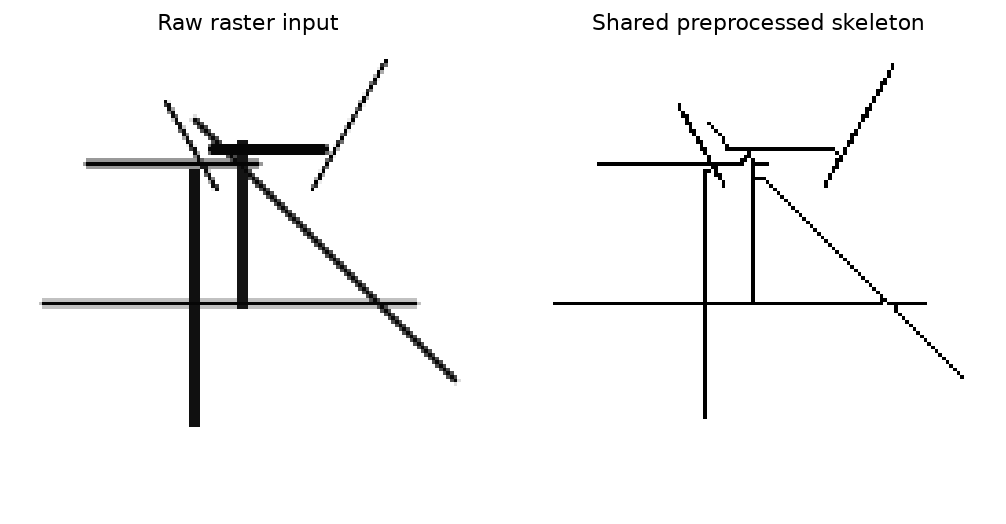

In [8]:
# Shared preprocessing stage for all raster images.
# This is now the only place where skeletonization is applied before comparison.

PREPROCESS_CONFIG = {
    "threshold": 0.5,
    "apply_skeletonization": True,
}


def skeleton_mask_to_raster_image(skeleton):
    """Convert a binary stroke mask into the notebook's raster format: black line on white background."""
    skeleton = (skeleton > 0).astype(np.uint8)
    return np.where(skeleton == 1, 0.0, 1.0).astype(np.float32)


def preprocess_raster_image(image, config=PREPROCESS_CONFIG):
    """Threshold a raster and reduce it to a single-pixel skeleton.

    Input image convention: 0 = black/stroke, 1 = white/background.
    Output image convention: same as input, but with a one-pixel stroke.
    """
    raw_stroke = (image <= float(config["threshold"])).astype(np.uint8)

    if config.get("apply_skeletonization", True):
        processed_stroke = skeletonize_zhang_suen(raw_stroke)
    else:
        processed_stroke = raw_stroke.copy()

    processed_image = skeleton_mask_to_raster_image(processed_stroke)
    debug = {
        "raw_stroke": raw_stroke,
        "skeleton": processed_stroke,
        "raw_stroke_pixels": int(raw_stroke.sum()),
        "processed_stroke_pixels": int(processed_stroke.sum()),
        "apply_skeletonization": bool(config.get("apply_skeletonization", True)),
    }
    return processed_image, debug


def preprocess_raster_dataset(images, config=PREPROCESS_CONFIG):
    processed_images = []
    debug_rows = []
    for image in images:
        processed_image, debug = preprocess_raster_image(image, config=config)
        processed_images.append(processed_image)
        debug_rows.append(debug)
    return np.stack(processed_images).astype(np.float32), debug_rows


train_images_preprocessed, train_preprocess_debug = preprocess_raster_dataset(train_images)
test_images_preprocessed, test_preprocess_debug = preprocess_raster_dataset(test_images)

print('Shared raster preprocessing complete:')
print({
    'train_images_preprocessed': train_images_preprocessed.shape,
    'test_images_preprocessed': test_images_preprocessed.shape,
    'threshold': PREPROCESS_CONFIG['threshold'],
    'apply_skeletonization': PREPROCESS_CONFIG['apply_skeletonization'],
})
print('\nFirst test image stroke pixels:')
print({
    'before_skeletonization': test_preprocess_debug[0]['raw_stroke_pixels'],
    'after_skeletonization': test_preprocess_debug[0]['processed_stroke_pixels'],
})

fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=130)
ax[0].imshow(test_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Raw raster input')
ax[0].axis('off')
ax[1].imshow(test_images_preprocessed[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title('Shared preprocessed skeleton')
ax[1].axis('off')
plt.tight_layout()
plt.show()


## Direct learned raster-to-vector models: MLP and CNN

These two models are **not junction classifiers**. They learn a direct mapping from the raster image to a fixed set of line vectors.

Input: shared preprocessed skeleton raster pixels.  
Label: original synthetic vector list encoded as fixed slots: `[confidence, x0, y0, x1, y1]`.  
Training objective: binary cross-entropy for whether a slot contains a line, plus Smooth L1 coordinate regression for the true line slots.


In [9]:
# Direct learned raster-to-vector methods: MLP and CNN
# -------------------------------------------------------
# These are NOT junction classifiers.
# They use the raster as input and the true vector list as supervised labels.
# Each model predicts MAX_VECTORS line slots:
#   [confidence, x0, y0, x1, y1]
# The coordinate loss is only applied to slots that contain a true vector.

import pandas as pd

DIRECT_VECTOR_MODEL_CONFIG = {
    "input_source": "preprocessed_skeleton",  # fair comparison: same raster used by baseline/skeleton graph
    "batch_size": 64,
    "mlp_epochs": MLP_EPOCHS,
    "cnn_epochs": CNN_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": 1e-4,
    "coord_loss_weight": 10.0,
    "no_object_conf_weight": 0.25,
    "confidence_threshold": 0.50,
    "train_mlp": True,
    "train_cnn": True,
}


def canonicalise_vector_for_learning(vector):
    """Use a stable endpoint order so the network is not asked to learn arbitrary reversals."""
    x0, y0, x1, y1 = map(float, vector[:4])
    if (x1, y1) < (x0, y0):
        x0, y0, x1, y1 = x1, y1, x0, y0
    return (x0, y0, x1, y1)


def sorted_vectors_for_learning(vectors):
    """Sort unordered vector labels into repeatable slots.

    This keeps supervised learning simple. It is still a limitation: line-vector prediction is
    naturally unordered, while this fixed-slot approach imposes an order.
    """
    canon = [canonicalise_vector_for_learning(v) for v in vectors]

    def key(v):
        x0, y0, x1, y1 = v
        cx = 0.5 * (x0 + x1)
        cy = 0.5 * (y0 + y1)
        length = math.hypot(x1 - x0, y1 - y0)
        angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
        return (round(cy, 3), round(cx, 3), round(angle, 3), round(length, 3))

    return sorted(canon, key=key)


def encode_vector_targets(vector_lists, max_vectors=MAX_VECTORS, img_size=IMG_SIZE):
    """Encode variable-length vector lists into fixed supervised-learning tensors."""
    n = len(vector_lists)
    target_conf = np.zeros((n, max_vectors), dtype=np.float32)
    target_coords = np.zeros((n, max_vectors, 4), dtype=np.float32)
    scale = float(img_size - 1)

    for i, vectors in enumerate(vector_lists):
        vectors = sorted_vectors_for_learning(vectors)[:max_vectors]
        for j, vector in enumerate(vectors):
            target_conf[i, j] = 1.0
            target_coords[i, j] = np.asarray(vector, dtype=np.float32) / scale

    return target_conf, target_coords


def make_direct_vector_tensors(images, vector_lists):
    """Create PyTorch tensors for direct vector regression.

    The notebook image convention is 0=stroke and 1=background. The model input uses
    1=stroke and 0=background, which is easier for the neural network.
    """
    x = (1.0 - images).astype(np.float32)
    x = torch.from_numpy(x[:, None, :, :])

    target_conf, target_coords = encode_vector_targets(vector_lists)
    y_conf = torch.from_numpy(target_conf)
    y_coords = torch.from_numpy(target_coords)
    return x, y_conf, y_coords


class DirectLineMLP(nn.Module):
    """Simple full-image MLP baseline: pixels -> vector slots."""
    def __init__(self, img_size=IMG_SIZE, max_vectors=MAX_VECTORS, hidden_dim=512, dropout=0.10):
        super().__init__()
        self.max_vectors = max_vectors
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_size * img_size, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, max_vectors * 5),
        )

    def forward(self, x):
        return self.net(x).view(x.shape[0], self.max_vectors, 5)


class DirectLineCNN(nn.Module):
    """Convolutional direct vector regressor: raster structure -> vector slots."""
    def __init__(self, max_vectors=MAX_VECTORS):
        super().__init__()
        self.max_vectors = max_vectors
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(512, max_vectors * 5),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x).view(x.shape[0], self.max_vectors, 5)


def direction_invariant_coord_loss(coord_pred, target_coords):
    """
    Coordinate loss where line direction does not matter.

    A predicted segment is compared against:
    1. target:         x0, y0, x1, y1
    2. reversed target: x1, y1, x0, y0

    The smaller loss is used.
    """
    target_reversed = target_coords[..., [2, 3, 0, 1]]

    loss_forward = F.smooth_l1_loss(
        coord_pred,
        target_coords,
        reduction='none'
    ).mean(dim=-1)

    loss_reversed = F.smooth_l1_loss(
        coord_pred,
        target_reversed,
        reduction='none'
    ).mean(dim=-1)

    return torch.minimum(loss_forward, loss_reversed).mean()

#----------
# Vector direction Ignored!!
#-----------

def direct_vector_loss(pred, target_conf, target_coords, config=DIRECT_VECTOR_MODEL_CONFIG):
    """
    BCE objectness + direction-invariant coordinate regression.

    This does not care whether the model predicts:
        A -> B
    or:
        B -> A

    Both are treated as the same line.
    """
    conf_logits = pred[..., 0]
    coord_pred = torch.sigmoid(pred[..., 1:])

    bce_raw = F.binary_cross_entropy_with_logits(
        conf_logits,
        target_conf,
        reduction='none'
    )

    noobj_weight = float(config["no_object_conf_weight"])

    bce_weights = torch.where(
        target_conf > 0.5,
        torch.ones_like(target_conf),
        torch.full_like(target_conf, noobj_weight),
    )

    conf_loss = (bce_raw * bce_weights).mean()

    positive_slots = target_conf > 0.5

    if positive_slots.any():
        coord_loss = direction_invariant_coord_loss(
            coord_pred[positive_slots],
            target_coords[positive_slots]
        )
    else:
        coord_loss = torch.zeros((), device=pred.device)

    total_loss = conf_loss + float(config["coord_loss_weight"]) * coord_loss

    return total_loss, conf_loss.detach(), coord_loss.detach()


def train_direct_vector_model(model_name, model, images, vector_lists, config=DIRECT_VECTOR_MODEL_CONFIG):
    x, y_conf, y_coords = make_direct_vector_tensors(images, vector_lists)
    dataset = TensorDataset(x, y_conf, y_coords)
    loader = DataLoader(
        dataset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        drop_last=False,
    )

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )

    epochs = int(config["mlp_epochs"] if model_name.lower().startswith('mlp') else config["cnn_epochs"])
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        total_conf = 0.0
        total_coord = 0.0
        n_batches = 0

        for xb, confb, coordsb in loader:
            xb = xb.to(DEVICE)
            confb = confb.to(DEVICE)
            coordsb = coordsb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss, conf_loss, coord_loss = direct_vector_loss(pred, confb, coordsb, config)
            loss.backward()
            optimizer.step()

            total += float(loss.item())
            total_conf += float(conf_loss.item())
            total_coord += float(coord_loss.item())
            n_batches += 1

        row = {
            "model": model_name,
            "epoch": epoch,
            "loss": total / max(n_batches, 1),
            "conf_loss": total_conf / max(n_batches, 1),
            "coord_loss": total_coord / max(n_batches, 1),
        }
        history.append(row)
        print(
            f'{model_name} epoch {epoch:02d}/{epochs}: '
            f'loss={row["loss"]:.4f}, '
            f'conf={row["conf_loss"]:.4f}, '
            f'coord={row["coord_loss"]:.4f}'
        )

    return model.eval(), pd.DataFrame(history)


def decode_direct_vector_prediction(
    pred,
    confidence_threshold=None,
    img_size=IMG_SIZE,
    min_length=MIN_VECTOR_LENGTH,
):
    """Decode one model prediction tensor into a list of line vectors."""
    if confidence_threshold is None:
        confidence_threshold = float(DIRECT_VECTOR_MODEL_CONFIG["confidence_threshold"])

    with torch.no_grad():
        conf = torch.sigmoid(pred[..., 0]).detach().cpu().numpy()
        coords = torch.sigmoid(pred[..., 1:]).detach().cpu().numpy()

    vectors = []
    confidences = []
    scale = float(img_size - 1)

    for slot_idx in np.argsort(-conf):
        score = float(conf[slot_idx])
        if score < confidence_threshold:
            continue

        x0, y0, x1, y1 = coords[slot_idx] * scale
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        if math.hypot(x1 - x0, y1 - y0) < min_length:
            continue

        vector = tuple(map(int, canonicalise_vector_for_learning((x0, y0, x1, y1))))
        if vector not in vectors:
            vectors.append(vector)
            confidences.append(score)

    return vectors, confidences


def predict_direct_vectors_from_image(model, image, model_name):
    """Comparison-method wrapper: one raster image -> predicted vectors + debug dict."""
    model.eval()
    x = torch.from_numpy((1.0 - image).astype(np.float32)[None, None, :, :]).to(DEVICE)
    with torch.no_grad():
        pred = model(x)[0]

    vectors, confidences = decode_direct_vector_prediction(pred)
    debug = {
        "model_type": model_name,
        "input_source": DIRECT_VECTOR_MODEL_CONFIG["input_source"],
        "confidence_threshold": DIRECT_VECTOR_MODEL_CONFIG["confidence_threshold"],
        "slot_confidences_above_threshold": confidences,
        "nodes": [],
        "paths": [],
        "classification_counts": {},
        "internal_skeletonization_applied": False,
    }
    return vectors, debug


# Fair setup for this notebook: train and evaluate the learned methods on the same shared
# preprocessed skeleton raster used by the rule-based comparison methods.
if DIRECT_VECTOR_MODEL_CONFIG["input_source"] == "preprocessed_skeleton":
    direct_train_images = train_images_preprocessed
else:
    direct_train_images = train_images

DIRECT_VECTOR_TRAINING_HISTORY = []

if DIRECT_VECTOR_MODEL_CONFIG["train_mlp"]:
    direct_mlp_model, direct_mlp_history = train_direct_vector_model(
        "mlp_direct_vector_regression_on_shared_skeleton",
        DirectLineMLP(),
        direct_train_images,
        train_vectors,
    )
    DIRECT_VECTOR_TRAINING_HISTORY.append(direct_mlp_history)

if DIRECT_VECTOR_MODEL_CONFIG["train_cnn"]:
    direct_cnn_model, direct_cnn_history = train_direct_vector_model(
        "cnn_direct_vector_regression_on_shared_skeleton",
        DirectLineCNN(),
        direct_train_images,
        train_vectors,
    )
    DIRECT_VECTOR_TRAINING_HISTORY.append(direct_cnn_history)

if DIRECT_VECTOR_TRAINING_HISTORY:
    direct_vector_training_history_df = pd.concat(DIRECT_VECTOR_TRAINING_HISTORY, ignore_index=True)
    display(direct_vector_training_history_df)
else:
    direct_vector_training_history_df = pd.DataFrame()
    print('Direct vector model training is disabled in DIRECT_VECTOR_MODEL_CONFIG.')


mlp_direct_vector_regression_on_shared_skeleton epoch 01/100: loss=0.6774, conf=0.3673, coord=0.0310
mlp_direct_vector_regression_on_shared_skeleton epoch 02/100: loss=0.4545, conf=0.1891, coord=0.0265
mlp_direct_vector_regression_on_shared_skeleton epoch 03/100: loss=0.4109, conf=0.1714, coord=0.0240
mlp_direct_vector_regression_on_shared_skeleton epoch 04/100: loss=0.3789, conf=0.1604, coord=0.0218
mlp_direct_vector_regression_on_shared_skeleton epoch 05/100: loss=0.3513, conf=0.1539, coord=0.0197
mlp_direct_vector_regression_on_shared_skeleton epoch 06/100: loss=0.3189, conf=0.1424, coord=0.0176
mlp_direct_vector_regression_on_shared_skeleton epoch 07/100: loss=0.2797, conf=0.1263, coord=0.0153
mlp_direct_vector_regression_on_shared_skeleton epoch 08/100: loss=0.2442, conf=0.1085, coord=0.0136
mlp_direct_vector_regression_on_shared_skeleton epoch 09/100: loss=0.2123, conf=0.0914, coord=0.0121
mlp_direct_vector_regression_on_shared_skeleton epoch 10/100: loss=0.1825, conf=0.0751, coo

,model,epoch,loss,conf_loss,coord_loss
0,mlp_direct_vector_regression_on_shared_skeleton,1,0.677375,0.367304,0.031007
1,mlp_direct_vector_regression_on_shared_skeleton,2,0.454517,0.189116,0.026540
2,mlp_direct_vector_regression_on_shared_skeleton,3,0.410922,0.171353,0.023957
3,mlp_direct_vector_regression_on_shared_skeleton,4,0.378906,0.160430,0.021848
4,mlp_direct_vector_regression_on_shared_skeleton,5,0.351266,0.153904,0.019736
...,...,...,...,...,...
195,cnn_direct_vector_regression_on_shared_skeleton,96,0.019028,0.002401,0.001663
196,cnn_direct_vector_regression_on_shared_skeleton,97,0.018441,0.002472,0.001597
197,cnn_direct_vector_regression_on_shared_skeleton,98,0.018742,0.002245,0.001650
198,cnn_direct_vector_regression_on_shared_skeleton,99,0.018586,0.002086,0.001650


# Plot how the direct ML vector models learnt

,model,epoch,loss,conf_loss,coord_loss
190,cnn_direct_vector_regression_on_shared_skeleton,91,0.0187,0.0024,0.0016
191,cnn_direct_vector_regression_on_shared_skeleton,92,0.0195,0.0025,0.0017
192,cnn_direct_vector_regression_on_shared_skeleton,93,0.0200,0.0024,0.0018
193,cnn_direct_vector_regression_on_shared_skeleton,94,0.0185,0.0023,0.0016
194,cnn_direct_vector_regression_on_shared_skeleton,95,0.0179,0.0021,0.0016
195,cnn_direct_vector_regression_on_shared_skeleton,96,0.0190,0.0024,0.0017
196,cnn_direct_vector_regression_on_shared_skeleton,97,0.0184,0.0025,0.0016
197,cnn_direct_vector_regression_on_shared_skeleton,98,0.0187,0.0022,0.0016
198,cnn_direct_vector_regression_on_shared_skeleton,99,0.0186,0.0021,0.0017
199,cnn_direct_vector_regression_on_shared_skeleton,100,0.0196,0.0026,0.0017


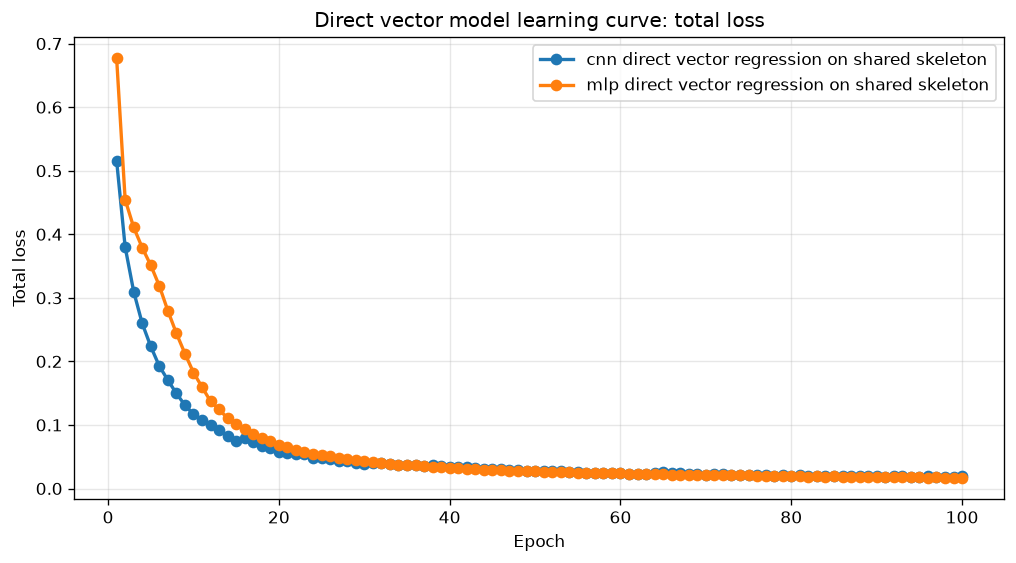

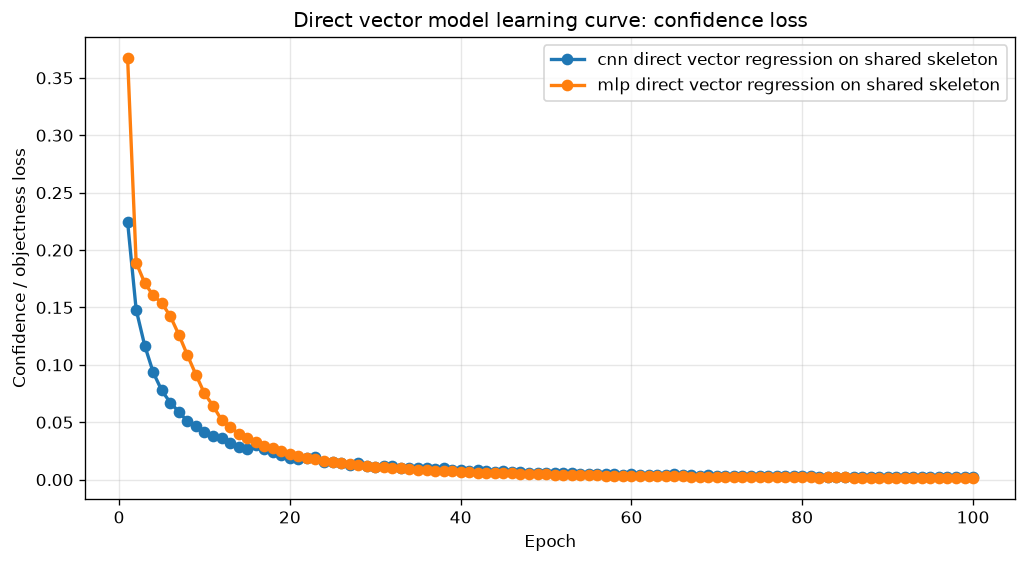

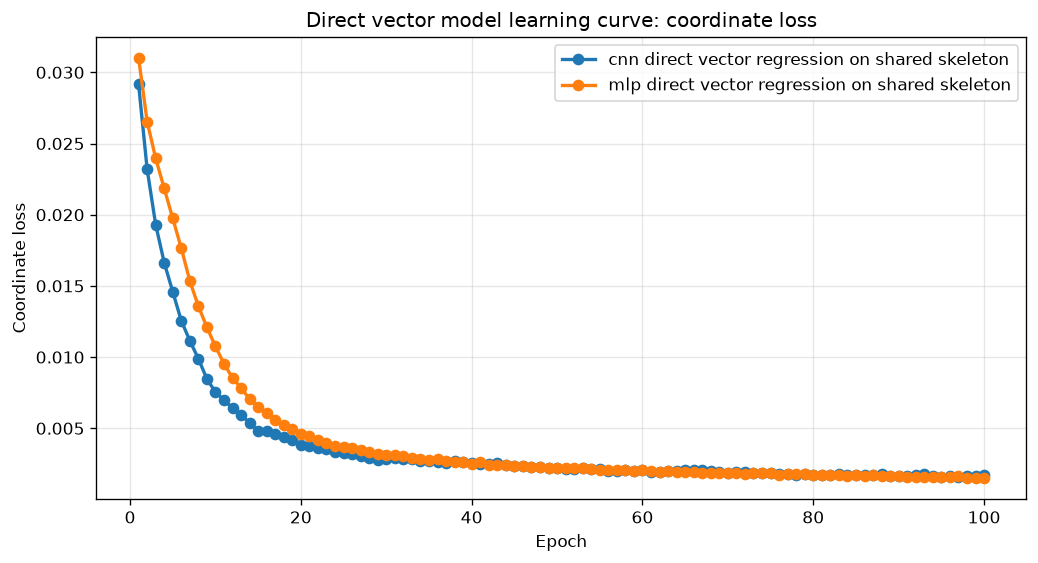

,model,first_loss,final_loss,best_loss,best_epoch,improvement_%
0,cnn_direct_vector_regression_on_shared_skeleton,0.5159,0.0196,0.0179,95,96.2025
1,mlp_direct_vector_regression_on_shared_skeleton,0.6774,0.0165,0.0165,100,97.5575


Reading the graphs:
- Total loss down = model is learning overall.
- Confidence loss down = model is learning how many line slots exist.
- Coordinate loss down = model is learning line endpoint positions.
- If total loss flattens early, increase epochs or lower learning rate.
- If loss jumps up/down a lot, lower LEARNING_RATE, e.g. 1e-4.


In [14]:
if "direct_vector_training_history_df" not in globals():
    raise NameError(
        "direct_vector_training_history_df was not found. "
        "Run the direct MLP/CNN training cell first."
    )

history_df = direct_vector_training_history_df.copy()

if history_df.empty:
    raise ValueError("direct_vector_training_history_df is empty. No training history to plot.")

display(history_df.tail(10))

# ------------------------------------------------------------
# 1. Total loss over epochs
# ------------------------------------------------------------

plt.figure(figsize=(10, 5), dpi=120)

for model_name, group in history_df.groupby("model"):
    plt.plot(
        group["epoch"],
        group["loss"],
        marker="o",
        linewidth=2,
        label=model_name.replace("_", " ")
    )

plt.title("Direct vector model learning curve: total loss")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 2. Confidence loss over epochs
#    This shows how well the model learnt which vector slots exist.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5), dpi=120)

for model_name, group in history_df.groupby("model"):
    plt.plot(
        group["epoch"],
        group["conf_loss"],
        marker="o",
        linewidth=2,
        label=model_name.replace("_", " ")
    )

plt.title("Direct vector model learning curve: confidence loss")
plt.xlabel("Epoch")
plt.ylabel("Confidence / objectness loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 3. Coordinate loss over epochs
#    This shows how well the model learnt line endpoint positions.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5), dpi=120)

for model_name, group in history_df.groupby("model"):
    plt.plot(
        group["epoch"],
        group["coord_loss"],
        marker="o",
        linewidth=2,
        label=model_name.replace("_", " ")
    )

plt.title("Direct vector model learning curve: coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Coordinate loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 4. Simple improvement report
# ------------------------------------------------------------

summary_rows = []

for model_name, group in history_df.groupby("model"):
    group = group.sort_values("epoch")

    first_loss = float(group["loss"].iloc[0])
    final_loss = float(group["loss"].iloc[-1])
    best_loss = float(group["loss"].min())
    best_epoch = int(group.loc[group["loss"].idxmin(), "epoch"])

    improvement_pct = 100.0 * (first_loss - final_loss) / max(first_loss, 1e-12)

    summary_rows.append({
        "model": model_name,
        "first_loss": first_loss,
        "final_loss": final_loss,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
        "improvement_%": improvement_pct,
    })

learning_summary_df = pd.DataFrame(summary_rows)
display(learning_summary_df)

print("Reading the graphs:")
print("- Total loss down = model is learning overall.")
print("- Confidence loss down = model is learning how many line slots exist.")
print("- Coordinate loss down = model is learning line endpoint positions.")
print("- If total loss flattens early, increase epochs or lower learning rate.")
print("- If loss jumps up/down a lot, lower LEARNING_RATE, e.g. 1e-4.")

## Original engineering metrics, reused

In [10]:
import pandas as pd
import numpy as np

METHODS = ["baseline", "mlp", "cnn"]


def raster_metrics(true_raster, pred_raster):
    """Pixel-overlap metrics are kept as a secondary check only."""
    true = true_raster < 0.5
    pred = pred_raster < 0.5

    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    tn = np.logical_and(~true, ~pred).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return precision, recall, f1, iou, accuracy


def vector_length_px(v):
    x0, y0, x1, y1 = v
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(v, config=GEOMETRY_CONFIG):
    """Return an undirected snapped angle in degrees: 0 and 180 are equivalent."""
    x0, y0, x1, y1 = v
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config["angle_unit_deg"])


def angle_distance_deg(a, b):
    """Smallest distance between two undirected line angles."""
    d = abs(a - b) % 180
    return min(d, 180 - d)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    """Return a programmable importance weight for an angle.

    Example: 90-degree family angles are more important than arbitrary 1-degree angles.
    This does not change the geometry; it changes how strongly the metric cares about mistakes.
    """
    best = min(config["angle_unit_weights"].values())
    for unit, weight in config["angle_unit_weights"].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        err = angle_distance_deg(angle_deg, nearest)
        if err <= config["angle_unit_deg"] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denom = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denom)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(v)) for v in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(v)) for v in pred_vectors)
    denom = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denom)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    """Compare lines by length and angle, not by absolute endpoint location.

    This is the key metric for your goal: a 10x10 square translated slightly should still score well
    because its line lengths and line angles are right.
    """
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for i, gt in enumerate(true_vectors):
        gt_len = snap_length_px(vector_length_px(gt), config["length_unit_px"])
        gt_ang = vector_angle_deg(gt, config)
        importance = angle_family_importance(gt_ang, config)

        for j, pred in enumerate(pred_vectors):
            pred_len = snap_length_px(vector_length_px(pred), config["length_unit_px"])
            pred_ang = vector_angle_deg(pred, config)

            angle_err = angle_distance_deg(gt_ang, pred_ang)
            length_err = abs(gt_len - pred_len)

            angle_part = max(0.0, 1.0 - angle_err / config["line_angle_tolerance_deg"])
            length_tol = max(config["length_unit_px"], config["length_tolerance_ratio"] * max(gt_len, 1.0))
            length_part = max(0.0, 1.0 - length_err / length_tol)

            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        weighted_score += pair_score * importance

    total_importance = sum(angle_family_importance(vector_angle_deg(v, config), config) for v in true_vectors)
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    """Return the acute angles at all places where two predicted/true segments meet or cross.

    This ignores the absolute location of the junction. It cares that the drawing contains the right
    kind of junctions, such as 90-degree corners in a square.
    """
    angles = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is None:
                continue
            a = vector_angle_deg(vectors[i], config)
            b = vector_angle_deg(vectors[j], config)
            d = angle_distance_deg(a, b)
            acute = min(d, 180 - d)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config["angle_unit_deg"]))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for i, a in enumerate(true_angles):
        for j, b in enumerate(pred_angles):
            err = abs(a - b)
            score = max(0.0, 1.0 - err / tolerance_deg)
            candidates.append((score, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config["junction_angle_tolerance_deg"],
    )

    w = config["score_weights"]
    engineering_score = (
        w["line_geometry"] * line_geometry
        + w["total_length"] * length_total
        + w["junction_angles"] * junction_angles
        + w["vector_count"] * count
    )

    return {
        "engineering_score": engineering_score,
        "line_geometry_score": line_geometry,
        "total_length_score": length_total,
        "junction_angle_score": junction_angles,
        "vector_count_score": count,
        "true_junctions": len(true_junction_angles),
        "pred_junctions": len(pred_junction_angles),
    }

## Compare rule-based methods against direct MLP/CNN vector regression

All methods are tested on `test_images_preprocessed`. Pixel-overlap metrics are measured against the preprocessed skeleton raster, while engineering metrics are measured against the original target vectors.


In [11]:
# Baseline, skeleton-graph junction fix, and direct learned vector-regression comparison.
# IMPORTANT: every comparison method receives test_images_preprocessed[idx].
# The MLP/CNN were trained to map raster pixels directly to true vector labels.

from IPython.display import display, Markdown

EXPORT_DIR = Path('complex_synthetic_data_skeleton_junction_exports')
EXPORT_DIR.mkdir(exist_ok=True)

METHODS_TO_COMPARE = {
    'baseline_on_shared_skeleton': lambda image: reconstruct_vectors_from_image(image, method='baseline'),
    'skeleton_graph_junction_fix_on_shared_skeleton': reconstruct_vectors_with_skeleton_junction_fix,
}

if 'direct_mlp_model' in globals():
    METHODS_TO_COMPARE['mlp_direct_vector_regression_on_shared_skeleton'] = (
        lambda image: predict_direct_vectors_from_image(
            direct_mlp_model,
            image,
            'mlp_direct_vector_regression_on_shared_skeleton',
        )
    )

if 'direct_cnn_model' in globals():
    METHODS_TO_COMPARE['cnn_direct_vector_regression_on_shared_skeleton'] = (
        lambda image: predict_direct_vectors_from_image(
            direct_cnn_model,
            image,
            'cnn_direct_vector_regression_on_shared_skeleton',
        )
    )

METHOD_DISPLAY_NAMES = {
    'baseline_on_shared_skeleton': 'Baseline on shared skeleton',
    'skeleton_graph_junction_fix_on_shared_skeleton': 'Skeleton graph junction fix',
    'mlp_direct_vector_regression_on_shared_skeleton': 'MLP direct vector regression',
    'cnn_direct_vector_regression_on_shared_skeleton': 'CNN direct vector regression',
}


def binary_confusion_counts(target_raster, pred_raster, threshold=0.5):
    """
    Binary confusion matrix for raster vectorisation.

    Assumes the notebook raster convention:
    - 0 = stroke / line pixel
    - 1 = background
    """
    target = np.asarray(target_raster) < threshold
    pred = np.asarray(pred_raster) < threshold

    tp = int(np.logical_and(target, pred).sum())
    fp = int(np.logical_and(~target, pred).sum())
    fn = int(np.logical_and(target, ~pred).sum())
    tn = int(np.logical_and(~target, ~pred).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision_from_matrix': precision,
        'recall_from_matrix': recall,
        'f1_from_matrix': f1,
        'accuracy_from_matrix': accuracy,
        'iou_from_matrix': iou,
    }


def confusion_matrix_from_counts(row):
    """
    Standard binary confusion matrix layout:

                    Pred background   Pred stroke
    True background       TN               FP
    True stroke           FN               TP
    """
    return np.array([
        [row['tn'], row['fp']],
        [row['fn'], row['tp']],
    ])


# Better table display in Jupyter.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)


comparison_outputs = {}
comparison_rows = []

for idx, (raw_image, preprocessed_image, true_vectors) in enumerate(
    zip(test_images, test_images_preprocessed, test_vectors)
):
    comparison_outputs[idx] = {}

    for method_name, method_fn in METHODS_TO_COMPARE.items():
        pred_vectors, debug = method_fn(preprocessed_image)
        debug['preprocessing'] = test_preprocess_debug[idx]

        comparison_outputs[idx][method_name] = {
            'vectors': pred_vectors,
            'debug': debug,
        }

        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)

        # Pixel metrics use the shared skeleton raster as the target, not the original thick raster.
        precision, recall, f1, iou, pixel_accuracy = raster_metrics(preprocessed_image, pred_raster)
        confusion = binary_confusion_counts(preprocessed_image, pred_raster)

        geom = engineering_metrics(true_vectors, pred_vectors, GEOMETRY_CONFIG)
        class_counts = debug.get('classification_counts', {})

        comparison_rows.append({
            'method': method_name,
            'method_display': METHOD_DISPLAY_NAMES.get(method_name, method_name),
            'sample': idx,

            'true_vectors': len(true_vectors),
            'pred_vectors': len(pred_vectors),
            'vector_count_error': abs(len(true_vectors) - len(pred_vectors)),

            **geom,

            'pixel_precision_on_skeleton': precision,
            'pixel_recall_on_skeleton': recall,
            'pixel_f1_on_skeleton': f1,
            'pixel_iou_on_skeleton': iou,
            'pixel_accuracy_on_skeleton': pixel_accuracy,

            'tp': confusion['tp'],
            'fp': confusion['fp'],
            'fn': confusion['fn'],
            'tn': confusion['tn'],

            'precision_from_matrix': confusion['precision_from_matrix'],
            'recall_from_matrix': confusion['recall_from_matrix'],
            'f1_from_matrix': confusion['f1_from_matrix'],
            'accuracy_from_matrix': confusion['accuracy_from_matrix'],
            'iou_from_matrix': confusion['iou_from_matrix'],

            'raw_stroke_pixels': test_preprocess_debug[idx]['raw_stroke_pixels'],
            'skeleton_stroke_pixels': test_preprocess_debug[idx]['processed_stroke_pixels'],

            'graph_node_clusters': len(debug.get('nodes', [])),
            'traced_paths': len(debug.get('paths', [])),

            'classified_line_pixels': class_counts.get('line', np.nan),
            'classified_endpoint_pixels': class_counts.get('endpoint', np.nan),
            'classified_corner_pixels': class_counts.get('corner', np.nan),
            'classified_t_junction_pixels': class_counts.get('t_junction', np.nan),
            'classified_x_junction_pixels': class_counts.get('x_junction', np.nan),

            'internal_skeletonization_applied': debug.get('internal_skeletonization_applied', None),
        })


comparison_df = pd.DataFrame(comparison_rows)

summary_df = (
    comparison_df
    .groupby('method')
    .mean(numeric_only=True)
    .sort_values('engineering_score', ascending=False)
    .round(4)
)


# Confusion matrix totals.
confusion_summary_df = (
    comparison_df
    .groupby('method')[['tp', 'fp', 'fn', 'tn']]
    .sum()
)


# F1 / accuracy matrix.
f1_accuracy_matrix_df = comparison_df.groupby('method').agg(
    tp=('tp', 'sum'),
    fp=('fp', 'sum'),
    fn=('fn', 'sum'),
    tn=('tn', 'sum'),

    mean_precision=('precision_from_matrix', 'mean'),
    mean_recall=('recall_from_matrix', 'mean'),
    mean_f1=('f1_from_matrix', 'mean'),
    mean_accuracy=('accuracy_from_matrix', 'mean'),
    mean_iou=('iou_from_matrix', 'mean'),

    mean_engineering_score=('engineering_score', 'mean'),
    mean_vector_count_error=('vector_count_error', 'mean'),
)

# Recalculate global metrics from total TP/FP/FN/TN.
f1_accuracy_matrix_df['global_precision'] = (
    f1_accuracy_matrix_df['tp'] /
    (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['fp'] + 1e-9)
)

f1_accuracy_matrix_df['global_recall'] = (
    f1_accuracy_matrix_df['tp'] /
    (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['fn'] + 1e-9)
)

f1_accuracy_matrix_df['global_f1'] = (
    2 * f1_accuracy_matrix_df['global_precision'] * f1_accuracy_matrix_df['global_recall'] /
    (f1_accuracy_matrix_df['global_precision'] + f1_accuracy_matrix_df['global_recall'] + 1e-9)
)

f1_accuracy_matrix_df['global_accuracy'] = (
    (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['tn']) /
    (
        f1_accuracy_matrix_df['tp'] +
        f1_accuracy_matrix_df['fp'] +
        f1_accuracy_matrix_df['fn'] +
        f1_accuracy_matrix_df['tn'] +
        1e-9
    )
)

f1_accuracy_matrix_df['global_iou'] = (
    f1_accuracy_matrix_df['tp'] /
    (
        f1_accuracy_matrix_df['tp'] +
        f1_accuracy_matrix_df['fp'] +
        f1_accuracy_matrix_df['fn'] +
        1e-9
    )
)

f1_accuracy_matrix_df = f1_accuracy_matrix_df.round(4)


# Cleaner score table with the most important columns first.
score_matrix_df = f1_accuracy_matrix_df[[
    'global_precision',
    'global_recall',
    'global_f1',
    'global_accuracy',
    'global_iou',

    'mean_precision',
    'mean_recall',
    'mean_f1',
    'mean_accuracy',
    'mean_iou',

    'mean_engineering_score',
    'mean_vector_count_error',

    'tp',
    'fp',
    'fn',
    'tn',
]].sort_values('global_f1', ascending=False)


# Identity diagnostic only applies to the two deterministic graph-based methods.
identity_rows = []

if (
    'baseline_on_shared_skeleton' in METHODS_TO_COMPARE
    and 'skeleton_graph_junction_fix_on_shared_skeleton' in METHODS_TO_COMPARE
):
    for idx in range(len(test_images_preprocessed)):
        base_vectors = comparison_outputs[idx]['baseline_on_shared_skeleton']['vectors']
        graph_vectors = comparison_outputs[idx]['skeleton_graph_junction_fix_on_shared_skeleton']['vectors']

        identity_rows.append({
            'sample': idx,
            'same_vector_count': len(base_vectors) == len(graph_vectors),
            'exactly_same_vectors': base_vectors == graph_vectors,
        })

identity_df = pd.DataFrame(identity_rows)

if len(identity_df):
    identity_summary_df = (
        identity_df
        .agg({
            'same_vector_count': 'mean',
            'exactly_same_vectors': 'mean',
        })
        .rename('fraction_true')
        .to_frame()
    )
else:
    identity_summary_df = pd.DataFrame()


# Save outputs.
results_csv = EXPORT_DIR / 'all_methods_shared_preprocessing_results.csv'
summary_csv = EXPORT_DIR / 'all_methods_shared_preprocessing_summary.csv'
identity_csv = EXPORT_DIR / 'baseline_vs_skeleton_graph_junction_fix_identity_check.csv'
confusion_csv = EXPORT_DIR / 'all_methods_confusion_matrix.csv'
f1_accuracy_csv = EXPORT_DIR / 'all_methods_f1_accuracy_matrix.csv'
score_matrix_csv = EXPORT_DIR / 'all_methods_score_matrix.csv'

comparison_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv)
identity_df.to_csv(identity_csv, index=False)
confusion_summary_df.to_csv(confusion_csv)
f1_accuracy_matrix_df.to_csv(f1_accuracy_csv)
score_matrix_df.to_csv(score_matrix_csv)


# Display output with comfortable spacing.
display(Markdown("# Rule-based vs Direct Learned Vector Prediction"))

display(Markdown("## Data / constants kept from original notebook"))

constants_df = pd.DataFrame([{
    'IMG_SIZE': IMG_SIZE,
    'MAX_VECTORS': MAX_VECTORS,
    'LINE_WIDTH': LINE_WIDTH,
    'N_TRAIN_IMAGES': N_TRAIN_IMAGES,
    'N_TEST': N_TEST,
    'PATCH_SIZE': PATCH_SIZE,
    'JUNCTION_RADIUS': JUNCTION_RADIUS,
    'MIN_VECTOR_LENGTH': MIN_VECTOR_LENGTH,
    'MAX_MERGE_PASSES': MAX_MERGE_PASSES,
}])

display(constants_df)


display(Markdown("## Comparison setup"))

setup_df = pd.DataFrame([
    {
        'item': 'comparison_input',
        'value': 'shared preprocessed one-pixel skeleton raster',
    },
    {
        'item': 'skeletonization',
        'value': 'applied once in preprocessing before rule-based and learned methods run',
    },
    {
        'item': 'baseline_rule',
        'value': 'neighbour_count >= 3',
    },
    {
        'item': 'skeleton_graph_rule',
        'value': 'classify endpoints/corners/T/X nodes, group nodes, trace branches from node centres',
    },
    {
        'item': 'mlp_direct_regression',
        'value': 'raster pixels -> fixed vector slots, trained with true vectors by backpropagation',
    },
    {
        'item': 'cnn_direct_regression',
        'value': 'convolutional raster encoder -> fixed vector slots, trained with true vectors by backpropagation',
    },
])

display(setup_df)


display(Markdown("## Methods compared"))
display(pd.DataFrame({'method': list(METHODS_TO_COMPARE.keys())}))


display(Markdown("## Skeleton graph config"))

display(pd.DataFrame([SKELETON_GRAPH_CONFIG]))

if 'DIRECT_VECTOR_MODEL_CONFIG' in globals():
    display(Markdown("## Direct vector model config"))
    display(pd.DataFrame([DIRECT_VECTOR_MODEL_CONFIG]))

if len(identity_summary_df):
    display(Markdown("## Are the two deterministic graph outputs identical?"))
    display(identity_summary_df)


display(Markdown("## Average method comparison"))

display(summary_df)


display(Markdown("## F1 / Accuracy Score Matrix"))

display(score_matrix_df)


display(Markdown("## Confusion matrix totals by method"))

display(confusion_summary_df)


display(Markdown("## Individual confusion matrices"))

for method_name, row in confusion_summary_df.iterrows():
    matrix = confusion_matrix_from_counts(row)

    matrix_df = pd.DataFrame(
        matrix,
        index=['true_background', 'true_stroke'],
        columns=['pred_background', 'pred_stroke']
    )

    display(Markdown(f"### {method_name}"))
    display(matrix_df)


display(Markdown("## First few per-sample rows"))

display(comparison_df.head(10))


display(Markdown("## Saved files"))

saved_files_df = pd.DataFrame({
    'file': [
        results_csv,
        summary_csv,
        identity_csv,
        confusion_csv,
        f1_accuracy_csv,
        score_matrix_csv,
    ]
})

display(saved_files_df)


# Rule-based vs Direct Learned Vector Prediction

## Data / constants kept from original notebook

,IMG_SIZE,MAX_VECTORS,LINE_WIDTH,N_TRAIN_IMAGES,N_TEST,PATCH_SIZE,JUNCTION_RADIUS,MIN_VECTOR_LENGTH,MAX_MERGE_PASSES
0,128,20,1,600,80,9,2,2.0000,2


## Comparison setup

,item,value
0,comparison_input,shared preprocessed one-pixel skeleton raster
1,skeletonization,applied once in preprocessing before rule-base...
2,baseline_rule,neighbour_count >= 3
3,skeleton_graph_rule,"classify endpoints/corners/T/X nodes, group no..."
4,mlp_direct_regression,"raster pixels -> fixed vector slots, trained w..."
5,cnn_direct_regression,convolutional raster encoder -> fixed vector s...


...

,pred_background,pred_stroke
true_background,1263546,7712
true_stroke,9412,30050


## First few per-sample rows

,method,method_display,sample,true_vectors,pred_vectors,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision_on_skeleton,pixel_recall_on_skeleton,pixel_f1_on_skeleton,pixel_iou_on_skeleton,pixel_accuracy_on_skeleton,tp,fp,fn,tn,precision_from_matrix,recall_from_matrix,f1_from_matrix,accuracy_from_matrix,iou_from_matrix,raw_stroke_pixels,skeleton_stroke_pixels,graph_node_clusters,traced_paths,classified_line_pixels,classified_endpoint_pixels,classified_corner_pixels,classified_t_junction_pixels,classified_x_junction_pixels,internal_skeletonization_applied
0,baseline_on_shared_skeleton,Baseline on shared skeleton,0,8,9,1,0.6987,0.6556,0.9626,0.4889,0.8889,9,9,0.7794,0.7352,0.7567,0.6086,0.9878,311,88,112,15873,0.7794,0.7352,0.7567,0.9878,0.6086,850,423,21,22,NaN,NaN,NaN,NaN,NaN,None
1,skeleton_graph_junction_fix_on_shared_skeleton,Skeleton graph junction fix,0,8,11,3,0.5618,0.5076,0.9143,0.3111,0.7273,9,8,0.6053,0.5437,0.5729,0.4014,0.9791,230,150,193,15811,0.6053,0.5437,0.5729,0.9791,0.4014,850,423,20,21,309.0000,11.0000,6.0000,66.0000,31.0000,False
2,mlp_direct_vector_regression_on_shared_skeleton,MLP direct vector regression,0,8,10,2,0.2942,0.1008,0.7055,0.1111,0.8000,9,8,0.0730,0.0473,0.0574,0.0295,0.9599,20,254,403,15707,0.0730,0.0473,0.0574,0.9599,0.0295,850,423,0,0,NaN,NaN,NaN,NaN,NaN,False
3,cnn_direct_vector_regression_on_shared_skeleton,CNN direct vector regression,0,8,12,4,0.3303,0.2203,0.7670,0.0444,0.6667,9,6,0.0541,0.0402,0.0461,0.0236,0.9571,17,297,406,15664,0.0541,0.0402,0.0461,0.9571,0.0236,850,423,0,0,NaN,NaN,NaN,NaN,NaN,False
4,baseline_on_shared_skeleton,Baseline on shared skeleton,1,7,9,2,0.6722,0.7515,0.8747,0.3250,0.7778,4,8,0.7360,0.7311,0.7336,0.5792,0.9901,223,80,82,15999,0.7360,0.7311,0.7336,0.9901,0.5792,597,305,17,14,NaN,NaN,NaN,NaN,NaN,None
5,skeleton_graph_junction_fix_on_shared_skeleton,Skeleton graph junction fix,1,7,9,2,0.6816,0.7712,0.8774,0.3250,0.7778,4,8,0.7393,0.7344,0.7368,0.5833,0.9902,224,79,81,16000,0.7393,0.7344,0.7368,0.9902,0.5833,597,305,17,14,270.0000,12.0000,1.0000,10.0000,12.0000,False
6,mlp_direct_vector_regression_on_shared_skeleton,MLP direct vector regression,1,7,7,0,0.3244,0.0754,0.7437,0.1667,1.0000,4,6,0.0496,0.0393,0.0439,0.0224,0.9681,12,230,293,15849,0.0496,0.0393,0.0439,0.9681,0.0224,597,305,0,0,NaN,NaN,NaN,NaN,NaN,False
7,cnn_direct_vector_regression_on_shared_skeleton,CNN direct vector regression,1,7,7,0,0.2885,0.1540,0.5961,0.0000,1.0000,4,4,0.0796,0.0525,0.0632,0.0327,0.9711,16,185,289,15894,0.0796,0.0525,0.0632,0.9711,0.0327,597,305,0,0,NaN,NaN,NaN,NaN,NaN,False
8,baseline_on_shared_skeleton,Baseline on shared skeleton,2,2,2,0,0.9538,0.9121,0.9667,1.0000,1.0000,0,0,1.0000,1.0000,1.0000,1.0000,1.0000,89,0,0,16295,1.0000,1.0000,1.0000,1.0000,1.0000,284,89,4,2,NaN,NaN,NaN,NaN,NaN,None
9,skeleton_graph_junction_fix_on_shared_skeleton,Skeleton graph junction fix,2,2,2,0,0.9538,0.9121,0.9667,1.0000,1.0000,0,0,1.0000,1.0000,1.0000,1.0000,1.0000,89,0,0,16295,1.0000,1.0000,1.0000,1.0000,1.0000,284,89,4,2,85.0000,4.0000,0.0000,0.0000,0.0000,False


## Saved files

,file
0,complex_synthetic_data_skeleton_junction_expor...
1,complex_synthetic_data_skeleton_junction_expor...
2,complex_synthetic_data_skeleton_junction_expor...
3,complex_synthetic_data_skeleton_junction_expor...
4,complex_synthetic_data_skeleton_junction_expor...
5,complex_synthetic_data_skeleton_junction_expor...


## Visual check across all comparison methods


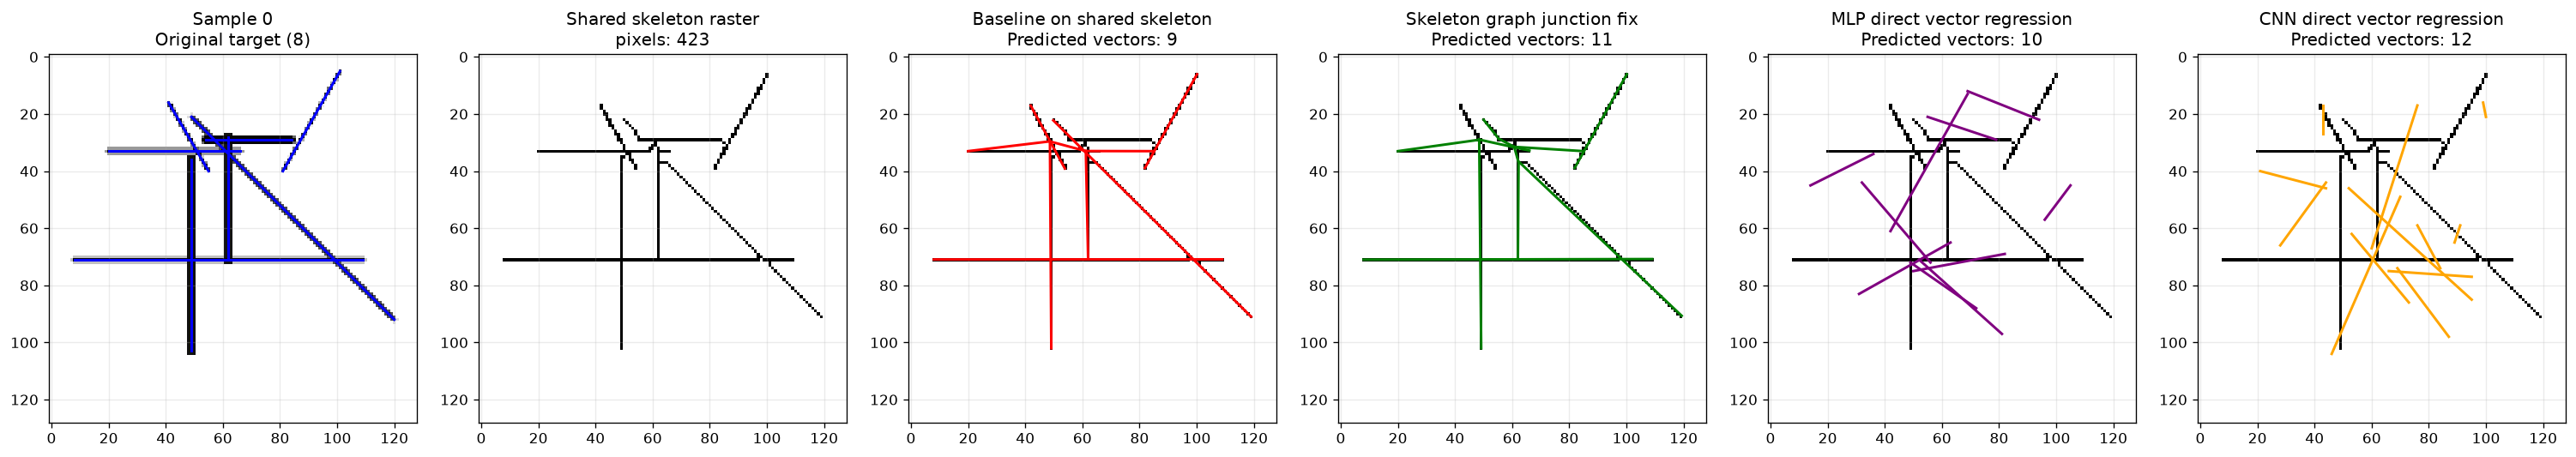

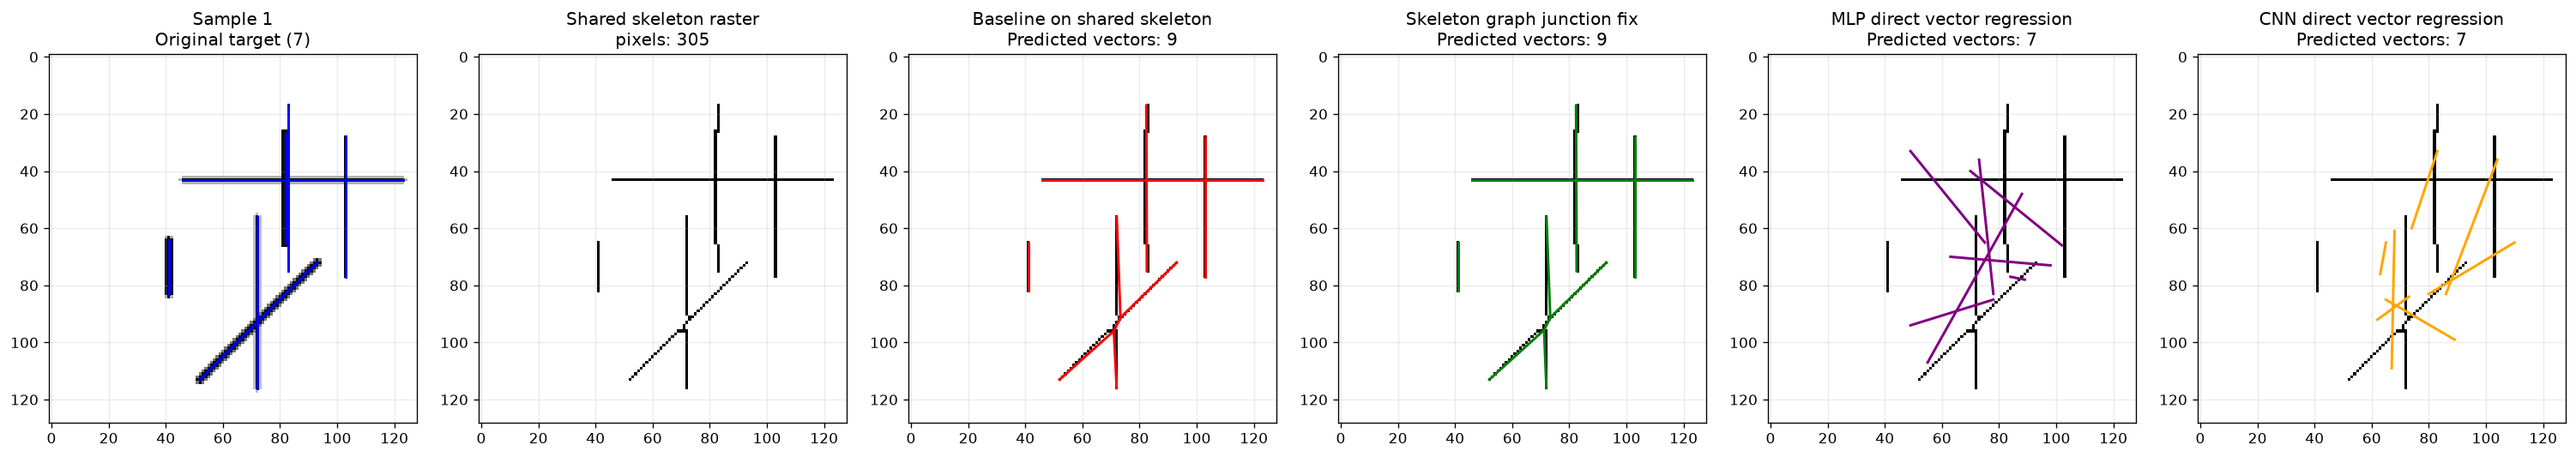

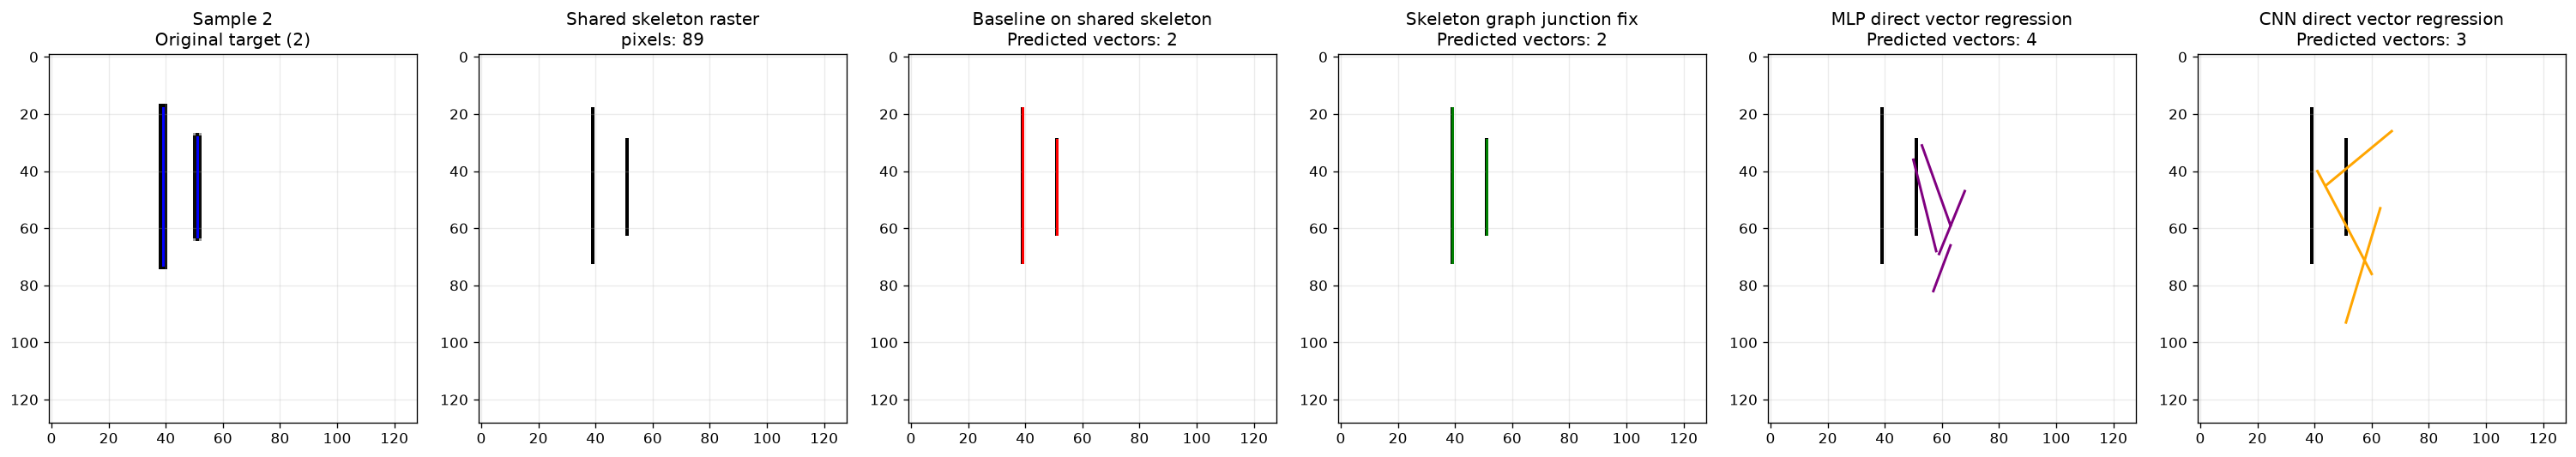

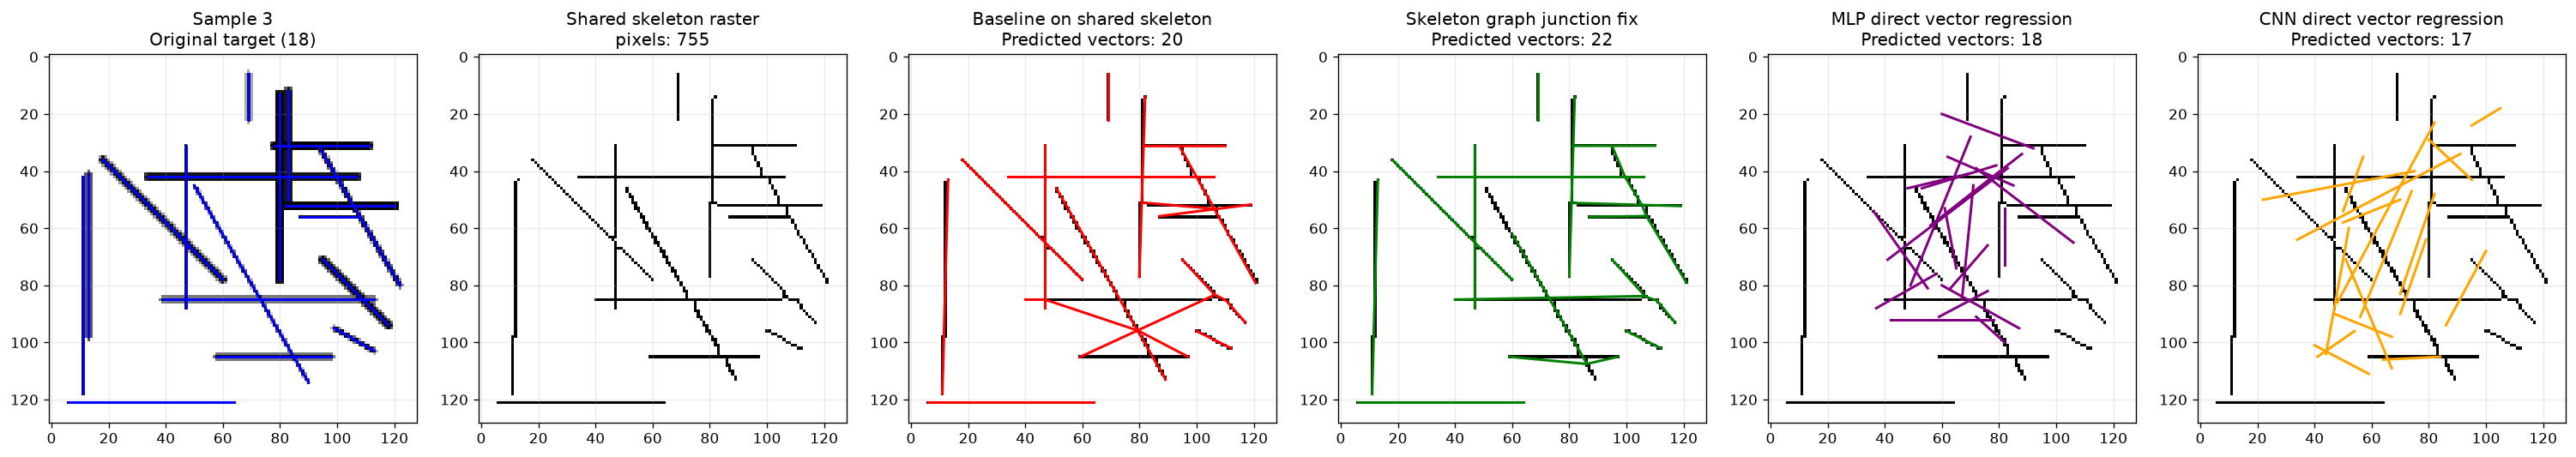

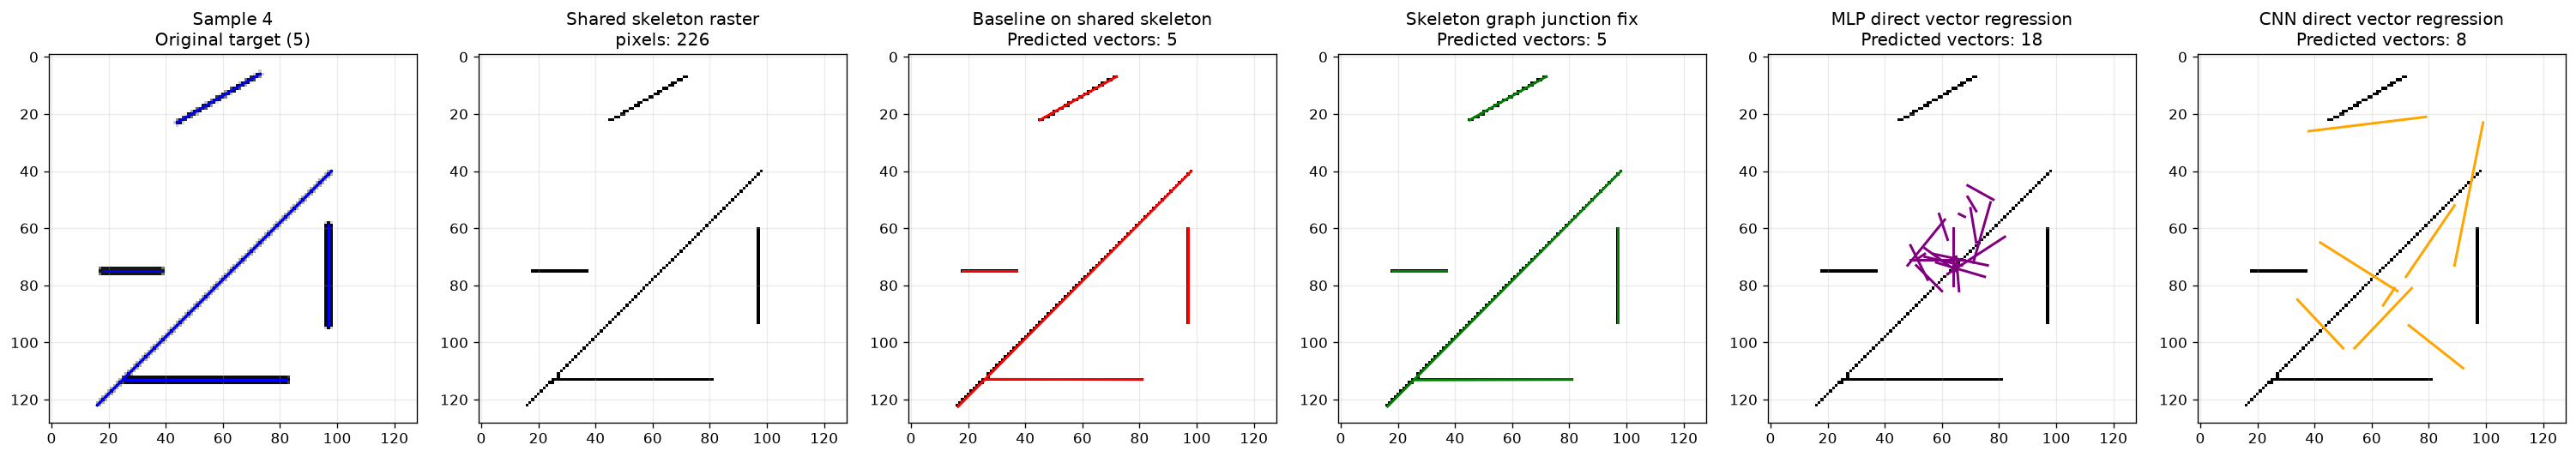

In [12]:

def draw_vectors(ax, image, vectors, title, colour='red'):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        ax.plot([x0, x1], [y0, y1], color=colour, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlim(-1, IMG_SIZE)
    ax.set_ylim(IMG_SIZE, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)


NUM_PREVIEWS = 5          # Change this to 1, 3, 10, 20, etc.
START_SAMPLE_INDEX = 0    # First sample to preview

# Use this instead if you want exact sample numbers.
# Example: SAMPLE_INDICES = [0, 4, 12, 20]
SAMPLE_INDICES = None


PREVIEW_COLOURS = {
    'Original target vectors': 'blue',
    'baseline_on_shared_skeleton': 'red',
    'skeleton_graph_junction_fix_on_shared_skeleton': 'green',
    'mlp_direct_vector_regression_on_shared_skeleton': 'purple',
    'cnn_direct_vector_regression_on_shared_skeleton': 'orange',
}


def method_title(method_name):
    return METHOD_DISPLAY_NAMES.get(method_name, method_name.replace('_', ' '))


def show_method_comparison(sample_idx=0):
    raw_image = test_images[sample_idx]
    preprocessed_image = test_images_preprocessed[sample_idx]
    original_vectors = test_vectors[sample_idx]
    prep = test_preprocess_debug[sample_idx]

    method_names = list(METHODS_TO_COMPARE.keys())
    ncols = 2 + len(method_names)
    fig, ax = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.5), dpi=120)

    draw_vectors(
        ax[0],
        raw_image,
        original_vectors,
        f'Sample {sample_idx}\nOriginal target ({len(original_vectors)})',
        PREVIEW_COLOURS['Original target vectors'],
    )

    ax[1].imshow(preprocessed_image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax[1].set_title(
        'Shared skeleton raster\n'
        f'pixels: {prep["processed_stroke_pixels"]}'
    )
    ax[1].set_xlim(-1, IMG_SIZE)
    ax[1].set_ylim(IMG_SIZE, -1)
    ax[1].set_aspect('equal')
    ax[1].grid(True, alpha=0.25)

    for col, method_name in enumerate(method_names, start=2):
        result = comparison_outputs[sample_idx][method_name]
        vectors = result['vectors']
        draw_vectors(
            ax[col],
            preprocessed_image,
            vectors,
            f'{method_title(method_name)}\nPredicted vectors: {len(vectors)}',
            PREVIEW_COLOURS.get(method_name, 'red'),
        )

    plt.tight_layout()
    plt.show()


def show_multiple_method_comparisons(
    num_previews=5,
    start_sample_index=0,
    sample_indices=None,
):
    if sample_indices is None:
        sample_indices = range(
            start_sample_index,
            start_sample_index + num_previews,
        )
    else:
        sample_indices = list(sample_indices)

    for sample_idx in sample_indices:
        show_method_comparison(sample_idx)


show_multiple_method_comparisons(
    num_previews=NUM_PREVIEWS,
    start_sample_index=START_SAMPLE_INDEX,
    sample_indices=SAMPLE_INDICES,
)


In [15]:
OUTPUT_DIR = Path("direct-learning-images")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_direct_method_comparison_image(
    sample_indices=None,
    num_previews=10,
    start_sample_index=0,
    output_name="direct_methods_samples_0_to_9",
    rows_per_image=2,
    dpi=220,
    cell_width=4.5,
    cell_height=4.5,
    show_after_saving=False,
):
    """
    Saves zoomable PNG comparison grids without freezing Jupyter.

    Instead of one enormous image, this saves chunks:
    - rows_per_image=1 gives one image per sample
    - rows_per_image=2 gives two samples per image
    - rows_per_image=5 gives five samples per image

    Requires:
    - test_images
    - test_images_preprocessed
    - test_vectors
    - test_preprocess_debug
    - comparison_outputs
    - METHODS_TO_COMPARE
    - METHOD_DISPLAY_NAMES
    - PREVIEW_COLOURS
    - draw_vectors
    """

    if sample_indices is None:
        sample_indices = list(range(start_sample_index, start_sample_index + num_previews))
    else:
        sample_indices = list(sample_indices)

    method_names = list(METHODS_TO_COMPARE.keys())
    ncols = 2 + len(method_names)

    saved_files = []

    for chunk_start in range(0, len(sample_indices), rows_per_image):
        chunk_indices = sample_indices[chunk_start:chunk_start + rows_per_image]

        nrows = len(chunk_indices)

        fig, ax = plt.subplots(
            nrows,
            ncols,
            figsize=(cell_width * ncols, cell_height * nrows),
            dpi=dpi,
            squeeze=False,
        )

        for row, sample_idx in enumerate(chunk_indices):
            raw_image = test_images[sample_idx]
            preprocessed_image = test_images_preprocessed[sample_idx]
            original_vectors = test_vectors[sample_idx]
            prep = test_preprocess_debug[sample_idx]

            draw_vectors(
                ax[row, 0],
                raw_image,
                original_vectors,
                f"Sample {sample_idx}\nOriginal target ({len(original_vectors)})",
                PREVIEW_COLOURS["Original target vectors"],
            )

            ax[row, 1].imshow(
                preprocessed_image,
                cmap="gray",
                vmin=0,
                vmax=1,
                interpolation="nearest",
            )
            ax[row, 1].set_title(
                "Shared skeleton raster\n"
                f'pixels: {prep["processed_stroke_pixels"]}'
            )
            ax[row, 1].set_xlim(-1, IMG_SIZE)
            ax[row, 1].set_ylim(IMG_SIZE, -1)
            ax[row, 1].set_aspect("equal")
            ax[row, 1].grid(True, alpha=0.25)

            for col, method_name in enumerate(method_names, start=2):
                result = comparison_outputs[sample_idx][method_name]
                vectors = result["vectors"]

                draw_vectors(
                    ax[row, col],
                    preprocessed_image,
                    vectors,
                    f"{method_title(method_name)}\nPredicted vectors: {len(vectors)}",
                    PREVIEW_COLOURS.get(method_name, "red"),
                )

        plt.tight_layout()

        first_idx = chunk_indices[0]
        last_idx = chunk_indices[-1]

        image_path = OUTPUT_DIR / f"{output_name}_samples_{first_idx}_to_{last_idx}.png"

        fig.savefig(
            image_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )

        saved_files.append(image_path)

        if show_after_saving:
            plt.show()
        else:
            plt.close(fig)

        print(f"Saved: {image_path}")

    print("\nFinished saving image files:")
    for path in saved_files:
        print(f" - {path}")

    return saved_files

In [16]:
save_direct_method_comparison_image(
    num_previews=10,
    start_sample_index=0,
    output_name="direct_methods_samples_0_to_9_large",
    rows_per_image=2,
    dpi=220,
    cell_width=4.5,
    cell_height=4.5,
    show_after_saving=False,
)

Saved: direct-learning-images\direct_methods_samples_0_to_9_large_samples_0_to_1.png
Saved: direct-learning-images\direct_methods_samples_0_to_9_large_samples_2_to_3.png
Saved: direct-learning-images\direct_methods_samples_0_to_9_large_samples_4_to_5.png
Saved: direct-learning-images\direct_methods_samples_0_to_9_large_samples_6_to_7.png
Saved: direct-learning-images\direct_methods_samples_0_to_9_large_samples_8_to_9.png

Finished saving image files:
 - direct-learning-images\direct_methods_samples_0_to_9_large_samples_0_to_1.png
 - direct-learning-images\direct_methods_samples_0_to_9_large_samples_2_to_3.png
 - direct-learning-images\direct_methods_samples_0_to_9_large_samples_4_to_5.png
 - direct-learning-images\direct_methods_samples_0_to_9_large_samples_6_to_7.png
 - direct-learning-images\direct_methods_samples_0_to_9_large_samples_8_to_9.png


[WindowsPath('direct-learning-images/direct_methods_samples_0_to_9_large_samples_0_to_1.png'),
 WindowsPath('direct-learning-images/direct_methods_samples_0_to_9_large_samples_2_to_3.png'),
 WindowsPath('direct-learning-images/direct_methods_samples_0_to_9_large_samples_4_to_5.png'),
 WindowsPath('direct-learning-images/direct_methods_samples_0_to_9_large_samples_6_to_7.png'),
 WindowsPath('direct-learning-images/direct_methods_samples_0_to_9_large_samples_8_to_9.png')]

## Layered SVG export for all comparison methods


In [13]:
from pathlib import Path
import re
import xml.etree.ElementTree as ET

SVG_NS = 'http://www.w3.org/2000/svg'
INKSCAPE_NS = 'http://www.inkscape.org/namespaces/inkscape'
ET.register_namespace('', SVG_NS)
ET.register_namespace('inkscape', INKSCAPE_NS)

# Change this to wherever you want the SVG files saved.
# On Windows this path will point to your GitHub project exports folder.
EXPORT_DIR = Path(r"C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

LAYER_COLOURS = {
    'Original target vectors': '#1f77b4',
    'baseline_on_shared_skeleton': '#d62728',
    'skeleton_graph_junction_fix_on_shared_skeleton': '#2ca02c',
    'mlp_direct_vector_regression_on_shared_skeleton': '#9467bd',
    'cnn_direct_vector_regression_on_shared_skeleton': '#ff7f0e',
}


def safe_layer_id(name):
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_').lower()


def add_line_layer(svg, layer_name, vectors, colour, stroke_width=1.0, visible=True):
    layer = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
        'id': safe_layer_id(layer_name),
        f'{{{INKSCAPE_NS}}}groupmode': 'layer',
        f'{{{INKSCAPE_NS}}}label': layer_name,
        'stroke': colour,
        'stroke-width': str(stroke_width),
        'fill': 'none',
        'stroke-linecap': 'round',
        'stroke-linejoin': 'round',
        'style': 'display:inline' if visible else 'display:none',
    })

    ET.SubElement(layer, f'{{{SVG_NS}}}title').text = layer_name

    for x0, y0, x1, y1 in vectors:
        ET.SubElement(layer, f'{{{SVG_NS}}}line', {
            'x1': f'{x0:.3f}',
            'y1': f'{y0:.3f}',
            'x2': f'{x1:.3f}',
            'y2': f'{y1:.3f}',
        })

    return layer


def export_all_methods_svg(sample_idx=0, filename=None, include_background=True):
    if filename is None:
        filename = EXPORT_DIR / f'sample_{sample_idx}_all_methods_vector_comparison.svg'

    scale = 6

    svg = ET.Element(f'{{{SVG_NS}}}svg', {
        'width': str(IMG_SIZE * scale),
        'height': str(IMG_SIZE * scale),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
        'version': '1.1',
    })

    if include_background:
        background = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
            'id': 'background',
            f'{{{INKSCAPE_NS}}}groupmode': 'layer',
            f'{{{INKSCAPE_NS}}}label': 'Background',
            'style': 'display:inline',
        })

        ET.SubElement(background, f'{{{SVG_NS}}}rect', {
            'x': '0',
            'y': '0',
            'width': str(IMG_SIZE),
            'height': str(IMG_SIZE),
            'fill': 'white',
        })

    add_line_layer(
        svg,
        'Original target vectors',
        test_vectors[sample_idx],
        LAYER_COLOURS['Original target vectors'],
        stroke_width=1.3,
    )

    for method_name in METHODS_TO_COMPARE.keys():
        add_line_layer(
            svg,
            METHOD_DISPLAY_NAMES.get(method_name, method_name),
            comparison_outputs[sample_idx][method_name]['vectors'],
            LAYER_COLOURS.get(method_name, '#000000'),
            stroke_width=1.0,
        )

    filename = Path(filename)
    ET.ElementTree(svg).write(filename, encoding='utf-8', xml_declaration=True)

    print(f'Saved layered SVG: {filename}')
    return filename


NUM_OUTPUT_EXAMPLES = 10
SAMPLE_INDICES = None

if SAMPLE_INDICES is None:
    SAMPLE_INDICES = range(min(NUM_OUTPUT_EXAMPLES, len(test_images)))

exported_svgs = [
    export_all_methods_svg(i)
    for i in SAMPLE_INDICES
]

exported_svgs


Saved layered SVG: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports\sample_0_all_methods_vector_comparison.svg
Saved layered SVG: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports\sample_1_all_methods_vector_comparison.svg
Saved layered SVG: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports\sample_2_all_methods_vector_comparison.svg
Saved layered SVG: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports\sample_3_all_methods_vector_comparison.svg
Saved layered SVG: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports\sample_4_all_methods_vector_comparison.svg
Saved layered SVG: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\exports\sample_5_all_methods_vector_comparison.svg
Saved layered SVG: C:\Users\

[WindowsPath('C:/Users/elmak/Documents/GitHub/Understanding-Artificial-Intelligence/vectorization-project/exports/sample_0_all_methods_vector_comparison.svg'),
 WindowsPath('C:/Users/elmak/Documents/GitHub/Understanding-Artificial-Intelligence/vectorization-project/exports/sample_1_all_methods_vector_comparison.svg'),
 WindowsPath('C:/Users/elmak/Documents/GitHub/Understanding-Artificial-Intelligence/vectorization-project/exports/sample_2_all_methods_vector_comparison.svg'),
 WindowsPath('C:/Users/elmak/Documents/GitHub/Understanding-Artificial-Intelligence/vectorization-project/exports/sample_3_all_methods_vector_comparison.svg'),
 WindowsPath('C:/Users/elmak/Documents/GitHub/Understanding-Artificial-Intelligence/vectorization-project/exports/sample_4_all_methods_vector_comparison.svg'),
 WindowsPath('C:/Users/elmak/Documents/GitHub/Understanding-Artificial-Intelligence/vectorization-project/exports/sample_5_all_methods_vector_comparison.svg'),
 WindowsPath('C:/Users/elmak/Documents/G